# RVX – Volatilitätsbasierte Frühindikatoren für ein Ampelsystem

### Eine explorative Datenanalyse des RVX (CBOE Russell 2000 Volatility Index)

Diese Analyse überträgt die Methodik des VIX-Notebooks auf den **RVX** und
untersucht neun Hypothesen zur Aussagekraft dieses Volatilitätsindex sowie
verwandter Kennzahlen als Bausteine für ein indikatorbasiertes **Ampelsystem**
(Grün = ruhiges Fahrwasser, Gelb = angespannt, Rot = Ausnahmezustand). Der RVX
bezieht sich dabei auf seinen eigenen zugrunde liegenden Aktienindex, den
**Russell 2000** – nicht auf den S&P 500. Ziel ist die Identifikation robuster
Signale sowie die datenbasierte Herleitung RVX-spezifischer Ampel-Schwellen.

Jede Hypothese wird in einheitlichen Schritten behandelt: Vorstellung und
Motivation, statistische bzw. grafische Auswertung, Interpretation der
Ergebnisse in allgemeinverständlicher Sprache sowie eine Einschätzung der
praktischen Relevanz für das Ampelsystem.

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenqualität und Aufbereitung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Vertiefte Einzelbetrachtung
6. Was-wäre-wenn-Analyse
7. Fazit und Handlungsempfehlungen


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des RVX sowie des
Russell 2000 als Vergleichsindex. Dieser Abschnitt beschreibt die verwendeten
Software-Werkzeuge und den Datenbezug.


### 1.1 Verwendete Bibliotheken und Konfiguration

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **matplotlib** / **seaborn** – grafische Auswertung.

Zentral definiert werden zudem der Datenpfad sowie die einheitlichen
Ampelfarben (Grün/Gelb/Rot) für sämtliche Diagramme des Notebooks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = "../data"

# Ampel-Farben für konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

### 1.2 Datenbezug

Die Rohdaten wurden per `src/fetch_data.py` bezogen (Volatilitätsindex RVX mit
Ticker `^RVX`, Aktienindex Russell 2000 mit Ticker `^RUT`, tägliche
OHLC-Daten) und liegen als CSV im Ordner `data/`. Der Beobachtungszeitraum
beginnt am 16.09.2009. Hinweis: Der RVX ist bei Yahoo Finance derzeit nicht abrufbar; die Historie stammt daher aus der offiziellen CBOE-Tageshistorie und beginnt am 16.09.2009.


In [2]:
rvx = pd.read_csv(f"{DATA_DIR}/rvx_raw.csv", index_col="Date", parse_dates=True)
russell2000 = pd.read_csv(f"{DATA_DIR}/russell2000_raw.csv", index_col="Date", parse_dates=True)

print("RVX:", rvx.shape, rvx.index.min().date(), "-", rvx.index.max().date())
print("Russell 2000:", russell2000.shape, russell2000.index.min().date(), "-", russell2000.index.max().date())

rvx.head()

RVX: (4245, 6) 2009-09-16 - 2026-08-10
Russell 2000: (4931, 6) 2007-01-03 - 2026-08-10


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2009-09-16,28.86,28.86,29.32,28.66,28.89,0
2009-09-17,29.60,29.60,30.13,28.74,29.11,0
2009-09-18,30.24,30.24,30.48,29.50,29.60,0
2009-09-21,29.92,29.92,32.16,29.89,32.09,0
2009-09-22,29.09,29.09,29.93,28.96,29.48,0


## 2. Datenqualität und Aufbereitung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf typische
Qualitätsprobleme geprüft und anschließend zu einem gemeinsamen Analyse-
Datensatz zusammengeführt.


### 2.1 Datenqualitätsprüfung

Geprüft werden fehlende Werte, doppelte Datumseinträge sowie abweichende
Handelstage zwischen den beiden Zeitreihen (z. B. durch unterschiedliche
Feiertagskalender bei Yahoo Finance).


In [3]:
print("Fehlende Werte RVX:\
", rvx.isna().sum())
print("\
Fehlende Werte Russell 2000:\
", russell2000.isna().sum())
print("\
Duplizierte Indexwerte RVX:", rvx.index.duplicated().sum())
print("Duplizierte Indexwerte Russell 2000:", russell2000.index.duplicated().sum())

only_in_rvx = rvx.index.difference(russell2000.index)
only_in_russell2000 = russell2000.index.difference(rvx.index)
print(f"\
Handelstage nur im RVX: {len(only_in_rvx)}")
print(f"Handelstage nur im Russell 2000: {len(only_in_russell2000)}")

Fehlende Werte RVX: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte Russell 2000: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte RVX: 0
Duplizierte Indexwerte Russell 2000: 0
Handelstage nur im RVX: 0
Handelstage nur im Russell 2000: 686


### 2.2 Kombinierter Analyse-Datensatz und Zielgrößen

Beide Zeitreihen werden über die gemeinsamen Handelstage verknüpft (inner
join). Zusätzlich werden die tägliche Russell 2000-Rendite (`russell2000_return`, in %)
sowie die tägliche RVX-Veränderung (`rvx_change`, in Punkten) als abgeleitete
Größen berechnet.


In [4]:
df = pd.DataFrame({
    "rvx_close": rvx["Close"],
    "russell2000_close": russell2000["Close"],
}).dropna()

df["russell2000_return"] = df["russell2000_close"].pct_change() * 100  # in %
df["rvx_change"] = df["rvx_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4245


,rvx_close,russell2000_close,russell2000_return,rvx_change
count,4245.000000,4245.000000,4244.000000,4244.000000
mean,23.734320,1482.253981,0.047602,-0.002274
std,7.603123,567.249610,1.425841,1.738807
min,11.830000,562.400024,-14.272017,-17.980000
25%,18.420000,1067.989990,-0.673252,-0.770000
50%,22.110000,1445.430054,0.084593,-0.090000
75%,26.850000,1908.089966,0.828146,0.610000
max,83.190000,3036.979980,9.391462,27.240000


## 3. Methodik und Hypothesenübersicht


### 3.1 Ampel-Logik und statistische Referenzgrößen

Als gemeinsame Referenzgröße für die vertiefenden Hypothesen dient der
RVX-Schwellenwert **34** – die datenbasiert (Abschnitt 4.4) hergeleitete
Grenze für den „Ausnahmezustand" (Rot). Anders als beim VIX (Faustregel 20/30)
werden die Schwellen 24/34 aus der RVX-eigenen Verteilung abgeleitet,
sodass sich vergleichbare Ampel-Anteile ergeben.

Zur Bewertung eines Signals wird durchgängig die **Trefferquote** verwendet:
der Anteil der Signaltage, an denen der RVX innerhalb der nächsten `horizon`
Handelstage mindestens einmal über die Schwelle steigt. Sie wird stets mit der
**Baseline** (unbedingte Wahrscheinlichkeit über alle Handelstage) verglichen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(hohe Autokorrelation, siehe Abschnitt 4.3). Die berichteten Trefferquoten sind
daher als Anhaltspunkt und nicht als exakte Wahrscheinlichkeitsaussage zu lesen.


In [5]:
# Gemeinsame Konfiguration für die folgenden Abschnitte.
# Die Ampel-Schwellen sind NICHT die VIX-Faustregeln 20/30, sondern datenbasiert
# aus der RVX-eigenen Verteilung abgeleitet (siehe Abschnitt 4.4), sodass sich
# vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb / 9 % Rot)
# ergeben.
RVX_THRESHOLD_GELB = 24  # Grenze Grün/Gelb (datenbasiert, Abschnitt 4.4)
RVX_THRESHOLD_ROT = 34   # Grenze Gelb/Rot, "Ausnahmezustand" (datenbasiert, Abschnitt 4.4)


def forward_hit_rate(signal_mask, horizon, threshold=RVX_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der RVX-Schlusskurs
    innerhalb der nächsten `horizon` Handelstage mindestens einmal über
    `threshold` steigt. Tage ohne vollständiges Folgefenster werden ausgeschlossen."""
    rvx_values = df["rvx_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = rvx_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)


# --- Prognosehorizonte und Vorwärts-Kennzahlen des Russell 2000 --------------------
# Ergänzend zur Trefferquote: Forward-Rendite (Kursveränderung bis horizon Tage
# später) und Forward-Max-Drawdown (größter zwischenzeitlicher Rückgang im
# Fenster [i, i+horizon]) des Russell 2000.
HORIZONS = [5, 10, 15, 30]


def forward_return(close, horizon):
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close, horizon):
    werte = close.values
    n = len(werte)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = werte[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for _h in HORIZONS:
    df[f"fwd_return_{_h}d"] = forward_return(df["russell2000_close"], _h)
    df[f"fwd_mdd_{_h}d"] = forward_max_drawdown(df["russell2000_close"], _h)


def forward_kennzahlen(signal_mask, horizon):
    """Mittlere Forward-Rendite und mittlerer Forward-Max-Drawdown des Russell 2000
    über `horizon` Handelstage für die markierten Tage."""
    maske = signal_mask.reindex(df.index).fillna(False)
    fr = df.loc[maske, f"fwd_return_{horizon}d"]
    mdd = df.loc[maske, f"fwd_mdd_{horizon}d"]
    return fr.mean(), mdd.mean(), int(fr.notna().sum())


print("Vorwärts-Kennzahlen berechnet für Horizonte:", HORIZONS)


Vorwärts-Kennzahlen berechnet für Horizonte: [5, 10, 15, 30]


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Ruhiges Fahrwasser vs. Stressphasen | Bewegt sich der RVX im ruhigen Band oder in einer Stressphase? |
| H2 | RVX vs. Russell 2000-Renditen | Wie hängt die RVX-Bewegung mit der Tagesrendite des Index zusammen? |
| H3 | Volatility Clustering | Treten hohe/niedrige RVX-Werte in Clustern auf (Autokorrelation)? |
| H4 | Verteilung & Schwellenwerte | Welche Ampel-Schwellen legt die historische Verteilung nahe? |
| H5 | Dauer der Ampelphasen | Wie lange dauern zusammenhängende Grün-/Gelb-/Rot-Phasen? |
| H6 | Neues 3-Monats-Hoch | Kündigt ein neues 3-Monats-Hoch eine nachfolgende Rot-Phase an? |
| H7 | 3-Punkte-Umkehr | Signalisiert eine ausgeprägte Intraday-Umkehr eine Beruhigung? |
| H8 | RVX-Schwellenwerte | Ab welchem Niveau heben sich reale Stressphasen ab? |
| H9 | Divergenz zum Index | Kündigt untypischer Gleichlauf von RVX und Index Turbulenzen an? |

H1–H5 bilden die Basis-Exploration des RVX, H6–H9 vertiefen einzelne, für
die Ampel-Logik besonders relevante Muster. Für jede Hypothese werden das
Ergebnis interpretiert und die Praxisrelevanz für das Ampelsystem eingeordnet.


## 4. Hypothesenanalyse

Die Abschnitte 4.1–4.5 prüfen die grundlegenden Eigenschaften des RVX,
die Abschnitte 4.6–4.9 vertiefen spezifische Signalmuster. Jeder Abschnitt
enthält Code, eine Visualisierung sowie eine Ergebnis- und Praxiseinordnung.


### 4.1 H1 – Ruhiges Fahrwasser vs. Stressphasen

**Hypothese:** Der RVX bewegt sich meist in einem ruhigen Band und zeigt nur
in Stressphasen (Corona-Crash 2020, Inflations-Baisse 2022) deutliche Ausschläge nach oben. Zur visuellen
Einordnung wird der RVX-Verlauf mit farblich hinterlegten Krisenphasen und den
datenbasierten Schwellen 24 und 34 dargestellt.


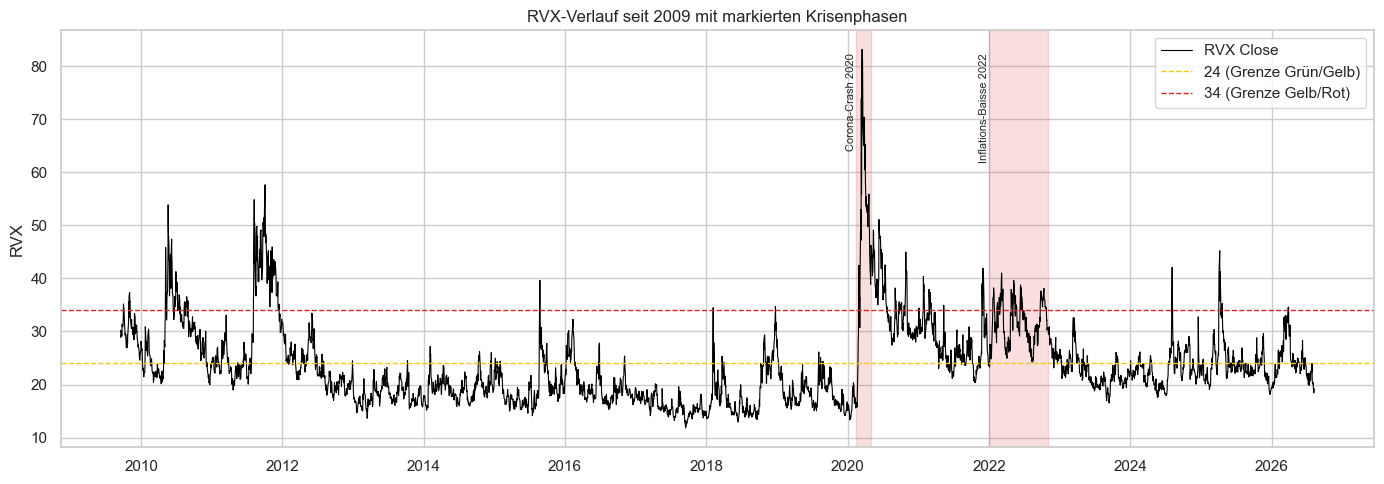

In [6]:
crisis_periods = {
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["rvx_close"], color="black", linewidth=0.8, label="RVX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(RVX_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", linewidth=1,
           label=f"{RVX_THRESHOLD_GELB} (Grenze Grün/Gelb)")
ax.axhline(RVX_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
           label=f"{RVX_THRESHOLD_ROT} (Grenze Gelb/Rot)")
ax.set_title("RVX-Verlauf seit 2009 mit markierten Krisenphasen")
ax.set_ylabel("RVX")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Auswertbare Tage - Baseline: 4215, >24: 1588, >34: 384
         Rend. Baseline Rend. >24 Rend. >34 MaxDD Baseline MaxDD >24 MaxDD >34
Horizont                                                                      
5T               +0.23%    +0.53%    +1.08%         -2.09%    -2.72%    -3.94%
10T              +0.46%    +1.00%    +2.02%         -3.37%    -4.28%    -5.85%
15T              +0.70%    +1.51%    +2.98%         -4.32%    -5.32%    -6.88%
30T              +1.38%    +3.16%    +5.28%         -6.44%    -7.35%    -8.99%


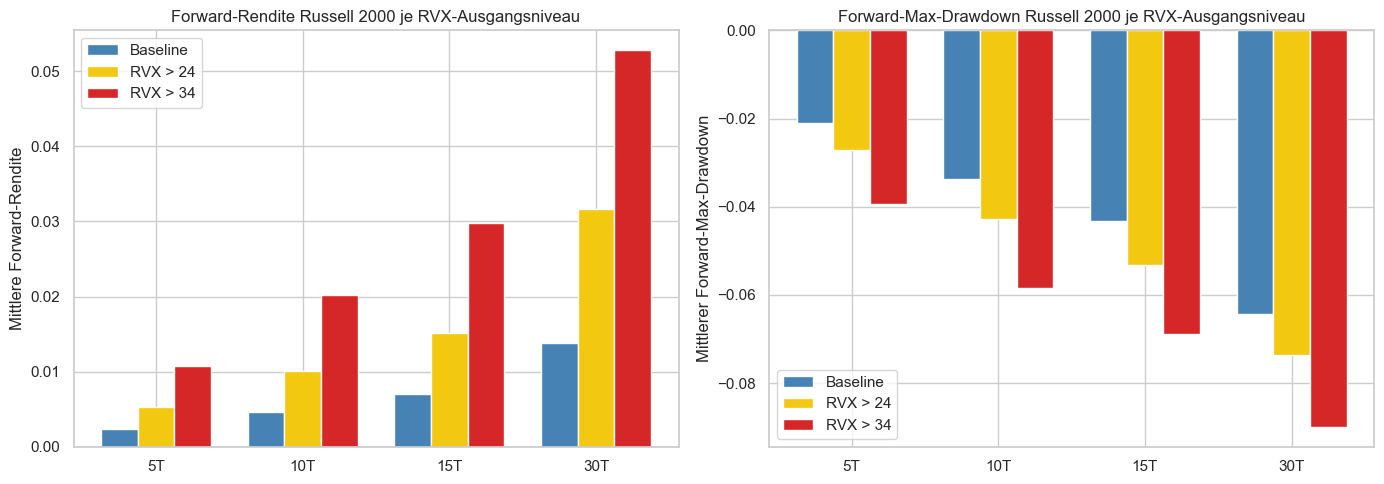

In [7]:
# Quantitative Ergänzung: Wie entwickelt sich der Russell 2000 nach Tagen mit erhöhtem
# RVX? Verglichen werden erhöhte Niveaus (RVX > 24 bzw. RVX > 34)
# mit der unbedingten Baseline (alle Handelstage).
maske_gelb = df["rvx_close"] > RVX_THRESHOLD_GELB
maske_rot = df["rvx_close"] > RVX_THRESHOLD_ROT

zeilen_h1 = []
for h in HORIZONS:
    fr_base, mdd_base, n_base = forward_kennzahlen(ALL_DAYS, h)
    fr_g, mdd_g, n_g = forward_kennzahlen(maske_gelb, h)
    fr_r, mdd_r, n_r = forward_kennzahlen(maske_rot, h)
    zeilen_h1.append({
        "Horizont": f"{h}T",
        "Rend. Baseline": fr_base, "Rend. >24": fr_g, "Rend. >34": fr_r,
        "MaxDD Baseline": mdd_base, "MaxDD >24": mdd_g, "MaxDD >34": mdd_r,
    })
tab_h1 = pd.DataFrame(zeilen_h1).set_index("Horizont")

disp_h1 = tab_h1.copy()
for spalte in disp_h1.columns:
    disp_h1[spalte] = tab_h1[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Tage - Baseline: {n_base}, >24: {n_g}, >34: {n_r}")
print(disp_h1.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.25
ax_r.bar(x - w, tab_h1["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.bar(x,     tab_h1["Rend. >24"],  w, label="RVX > 24", color=COLOR_YELLOW)
ax_r.bar(x + w, tab_h1["Rend. >34"],  w, label="RVX > 34", color=COLOR_RED)
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite Russell 2000 je RVX-Ausgangsniveau")
ax_r.legend()

ax_d.bar(x - w, tab_h1["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.bar(x,     tab_h1["MaxDD >24"],  w, label="RVX > 24", color=COLOR_YELLOW)
ax_d.bar(x + w, tab_h1["MaxDD >34"],  w, label="RVX > 34", color=COLOR_RED)
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown Russell 2000 je RVX-Ausgangsniveau")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Der RVX bewegt sich den überwiegenden Teil der Zeit unterhalb
von 24 und schießt in den markierten Krisenphasen sichtbar über 34. Die
Ausgangshypothese eines ruhigen Normalzustands mit seltenen, aber massiven
Ausschlägen wird damit klar bestätigt.

**Ergänzung – Forward-Kennzahlen des Russell 2000:** Ein erhöhter RVX ist historisch
kein Verkaufssignal. Nach Tagen mit RVX > 34 lag die mittlere Forward-Rendite
des Russell 2000 über 30 Tage bei +5,28 % und damit über
der Baseline (+1,38 %). Der Weg dorthin ist jedoch riskanter: Der
mittlere Forward-Max-Drawdown vertieft sich über 30 Tage von −6,44 %
(Baseline) auf −8,99 % (RVX > 34). Der RVX misst also Risiko und
Schwankungsbreite, nicht die Richtung.

**Praxisrelevanz für das Ampelsystem:** Die Grafik liefert die Grundlegitimation,
den RVX als Kernindikator einer Russell 2000-Ampel zu verwenden. Die Forward-Kennzahlen
schärfen die Lesart: Rot bedeutet „erhöhtes Schwankungs- und Drawdown-Risiko",
nicht „Kurse fallen sicher" – die Ampel steuert das Risiko, nicht die
Renditeerwartung.

### 4.2 H2 – RVX vs. Russell 2000-Renditen

**Hypothese:** Hohe RVX-Werte bzw. -Anstiege gehen mit negativen/volatilen
Russell 2000-Renditen einher (inverse Beziehung). Untersucht wird der Zusammenhang
zwischen (a) der täglichen RVX-Veränderung und (b) dem RVX-Niveau jeweils
gegenüber der Russell 2000-Tagesrendite (Pearson-Korrelation, Streudiagramme).


Korrelation RVX-Tagesänderung vs. Russell 2000-Tagesrendite: -0.756
Korrelation RVX-Niveau vs. Russell 2000-Tagesrendite: -0.113


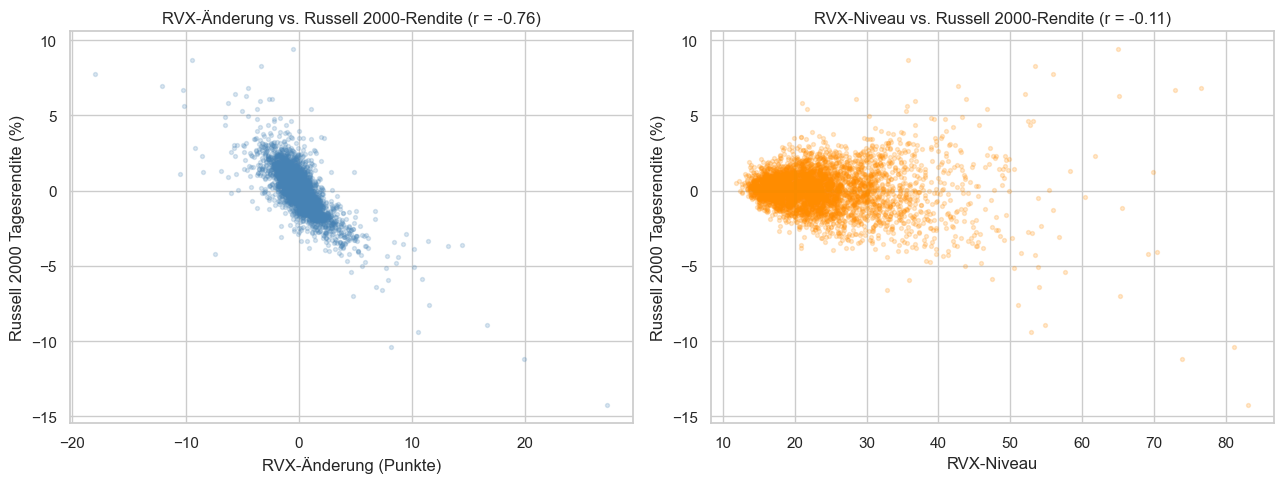

In [8]:
corr_change = df[["rvx_change", "russell2000_return"]].corr().iloc[0, 1]
corr_level = df[["rvx_close", "russell2000_return"]].corr().iloc[0, 1]
print(f"Korrelation RVX-Tagesänderung vs. Russell 2000-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation RVX-Niveau vs. Russell 2000-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["rvx_change"], df["russell2000_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("RVX-Änderung (Punkte)")
axes[0].set_ylabel("Russell 2000 Tagesrendite (%)")
axes[0].set_title(f"RVX-Änderung vs. Russell 2000-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["rvx_close"], df["russell2000_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("RVX-Niveau")
axes[1].set_ylabel("Russell 2000 Tagesrendite (%)")
axes[1].set_title(f"RVX-Niveau vs. Russell 2000-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

**Ergebnis:** Die tägliche RVX-Veränderung ist stark invers mit der
Russell 2000-Tagesrendite korreliert (r = −0,756) – steigt der RVX
deutlich, fällt der Index am selben Tag fast immer. Das reine RVX-Niveau sagt
dagegen kaum etwas über die Tagesrendite aus (r = −0,113).

**Praxisrelevanz für das Ampelsystem:** Der RVX eignet sich als
Zustandsindikator („wie angespannt ist der Markt"), nicht als Renditeprognose.
Rot heißt „erhöhte Vorsicht", nicht „der Markt fällt heute" – so sollte die
Morgenroutine kommuniziert werden.

### 4.3 H3 – Volatility Clustering (Autokorrelation)

**Hypothese:** Der RVX zeigt Volatility Clustering, d. h. hohe bzw. niedrige
Werte treten in Clustern auf statt zufällig zu springen. Gemessen wird die
Autokorrelation des RVX-Niveaus für Lags von 1 bis 20 Handelstagen – relevant
für die Stabilität einer täglichen Ampel.


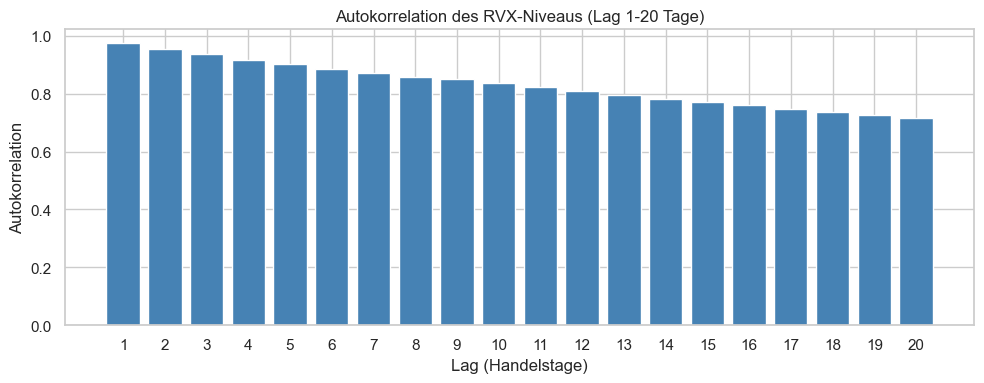

Autokorrelation Lag 1 (Vortag): 0.974
Autokorrelation Lag 5 (Vorwoche): 0.903


In [9]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["rvx_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des RVX-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['rvx_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['rvx_close'].autocorr(5):.3f}")

**Ergebnis:** Die Autokorrelation des RVX ist sowohl auf Tages-
(Lag 1: 0,974) als auch auf Wochensicht (Lag 5: 0,903)
extrem hoch. Der RVX ist damit ausgeprägt träge: ein hoher Wert heute macht
einen hohen Wert morgen sehr wahrscheinlich.

**Praxisrelevanz für das Ampelsystem:** Diese Trägheit ist für eine tägliche
Ampel ein Vorteil – die Farbe „flackert" nicht, sondern entwickelt sich stabil
über mehrere Tage. Das erhöht Glaubwürdigkeit und Akzeptanz des Signals.

### 4.4 H4 – Verteilung des RVX und Ampel-Schwellenwerte

**Hypothese:** Anhand der historischen Verteilung (Quantile) lassen sich
plausible Schwellenwerte für Grün/Gelb/Rot ableiten. Da der RVX ein anderes
typisches Niveau als der VIX hat, werden die Schwellen **nicht** von den
VIX-Faustregeln 20/30 übernommen, sondern so aus der RVX-Verteilung bestimmt,
dass sich vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb /
9 % Rot) ergeben. Geprüft wird, welcher Anteil der Handelstage in welche
Ampelphase fällt.


RVX-Quantile:
0.50    22.11
0.70    25.49
0.75    26.85
0.80    28.67
0.90    33.24
0.95    37.97
0.99    49.43
Name: rvx_close, dtype: float64


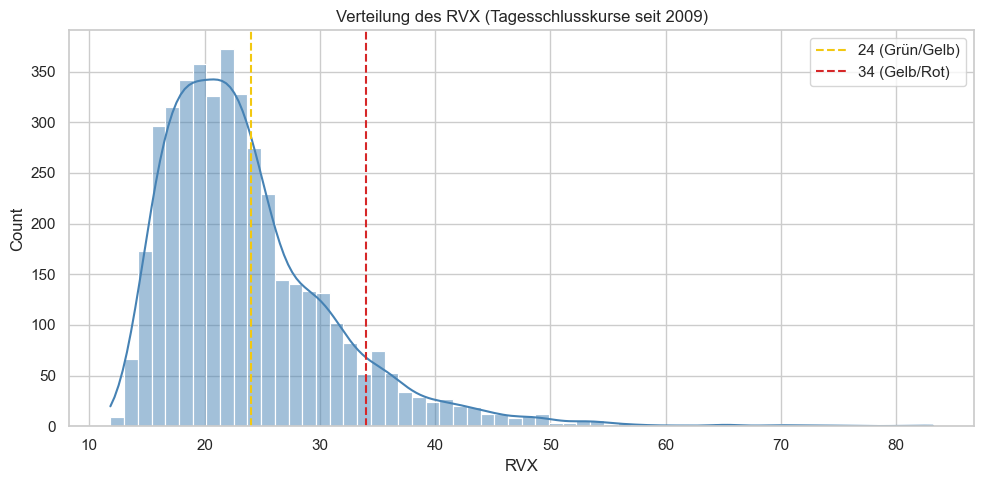

Grün (<24): 62.5% der Handelstage
Gelb (24-34): 28.4% der Handelstage
Rot (>34): 9.1% der Handelstage


In [10]:
quantiles = df["rvx_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("RVX-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["rvx_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(RVX_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", label=f"{RVX_THRESHOLD_GELB} (Grün/Gelb)")
ax.axvline(RVX_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", label=f"{RVX_THRESHOLD_ROT} (Gelb/Rot)")
ax.set_title("Verteilung des RVX (Tagesschlusskurse seit 2009)")
ax.set_xlabel("RVX")
ax.legend()
plt.tight_layout()
plt.show()

grenzen = [(0, RVX_THRESHOLD_GELB, f"Grün (<{RVX_THRESHOLD_GELB})"),
           (RVX_THRESHOLD_GELB, RVX_THRESHOLD_ROT, f"Gelb ({RVX_THRESHOLD_GELB}-{RVX_THRESHOLD_ROT})"),
           (RVX_THRESHOLD_ROT, np.inf, f"Rot (>{RVX_THRESHOLD_ROT})")]
for low, high, label in grenzen:
    share = ((df["rvx_close"] >= low) & (df["rvx_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")


**Ergebnis:** Die RVX-Verteilung ist rechtsschief (Median 22,1
unter Mittelwert 23,7). Die datenbasiert gewählten Schwellen
**24** und **34** teilen die Handelstage in 62,5 % Grün,
28,4 % Gelb und 9,1 % Rot – nahezu die gleichen Anteile wie
beim VIX (64 % / 27 % / 9 %) mit seinen Faustregeln 20/30. Die Perzentile
(50/75/90/95 = 22,1 / 26,9 / 33,2 /
38,0) stützen die Wahl: Die Grün/Gelb-Grenze 24 liegt nahe dem
75. Perzentil, die Rot-Grenze 34 nahe dem 90. Perzentil.

**Praxisrelevanz für das Ampelsystem:** Weil der RVX ein anderes Kursniveau
als der VIX hat, wären die VIX-Werte 20/30 hier ungeeignet gewesen. Die
datenbasierte Herleitung liefert RVX-eigene Schwellen mit vergleichbarer
Alarmhäufigkeit: Der Rot-Anteil von 9,1 % zeigt, wie oft die Routine
Alarm schlagen würde – selten genug, um „Alarm-Fatigue" zu vermeiden.

### 4.5 H5 – Dauer der Ampelphasen

**Hypothese:** Mit den datenbasierten Schwellen 24/34 wird jeder
Handelstag in Grün/Gelb/Rot klassifiziert; anschließend werden zusammenhängende
Phasen identifiziert und ihre Dauer ausgewertet – wichtig, um einzuschätzen, ob
die Ampel stabil genug für eine tägliche Routine ist.


In [11]:
def ampel(rvx_value: float) -> str:
    if rvx_value < RVX_THRESHOLD_GELB:
        return "grün"
    elif rvx_value < RVX_THRESHOLD_ROT:
        return "gelb"
    return "rot"

df["ampel"] = df["rvx_close"].apply(ampel)

phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\nDurchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\nDie 5 längsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())


Anzahl Phasenwechsel gesamt: 326

Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   162.0   7.438272  3.0   65.0
grün   119.0  22.310924  5.0  312.0
rot     45.0   8.555556  3.0   96.0

Die 5 längsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
146        rot 2020-03-05 2020-07-21          96
56         rot 2011-08-04 2011-12-14          93
18         rot 2010-05-14 2010-06-15          22
212        rot 2022-09-23 2022-10-24          22
20         rot 2010-06-22 2010-07-08          12


**Ergebnis:** Über den Zeitraum gab es 326 Phasenwechsel.
Rot-Phasen sind meist kurz (Median 3 Handelstage), können in
echten Krisen aber lange dauern (längste Phase 96 Tage). Mittelwert
(8,6) und Median (3) klaffen stark
auseinander – Rot ist meist ein kurzer Warnblinker, selten ein Dauerzustand.

**Praxisrelevanz für das Ampelsystem:** Ein einzelner Rot-Tag sollte keine
drastische Reaktion auslösen, da er statistisch meist nach wenigen Tagen abklingt.
Eine Eskalationsregel („Rot an 3+ Tagen in Folge = erhöhte Warnstufe") trennt
kurzfristiges Rauschen von echten Krisenphasen.

### 4.6 H6 – Neues 3-Monats-Hoch als Frühwarnsignal

**Hypothese:** Wenn der RVX ein neues 3-Monats-Hoch erreicht (höchster
Schlusskurs der vorangegangenen ca. 63 Handelstage), folgt in den nächsten
5 bzw. 10 Handelstagen überdurchschnittlich oft eine Phase mit RVX > 34.
Die Trefferquote wird mit der unbedingten Baseline verglichen.


In [12]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["rvx_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt über dem rollierenden 3-Monats-Hoch
new_3m_high = df["rvx_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 133
Trefferquote nach Signal, 5 Tage:  33.1%  (Baseline: 12.1%)
Trefferquote nach Signal, 10 Tage: 36.1%  (Baseline: 15.0%)


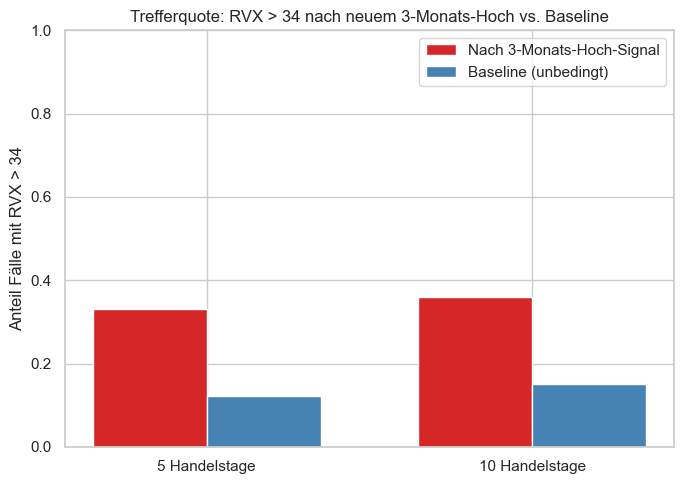

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Fälle mit RVX > {RVX_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: RVX > 34 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

Signaltage (neues 3-Monats-Hoch): 133
         Trefferq. Signal Trefferq. Baseline Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                                                            
5T                  33.1%              12.1%       +0.64%         +0.23%       -3.24%         -2.09%
10T                 36.1%              15.0%       +1.01%         +0.46%       -4.99%         -3.37%
15T                 37.6%              17.5%       +1.59%         +0.70%       -6.15%         -4.32%
30T                 39.8%              23.3%       +3.96%         +1.38%       -7.61%         -6.44%


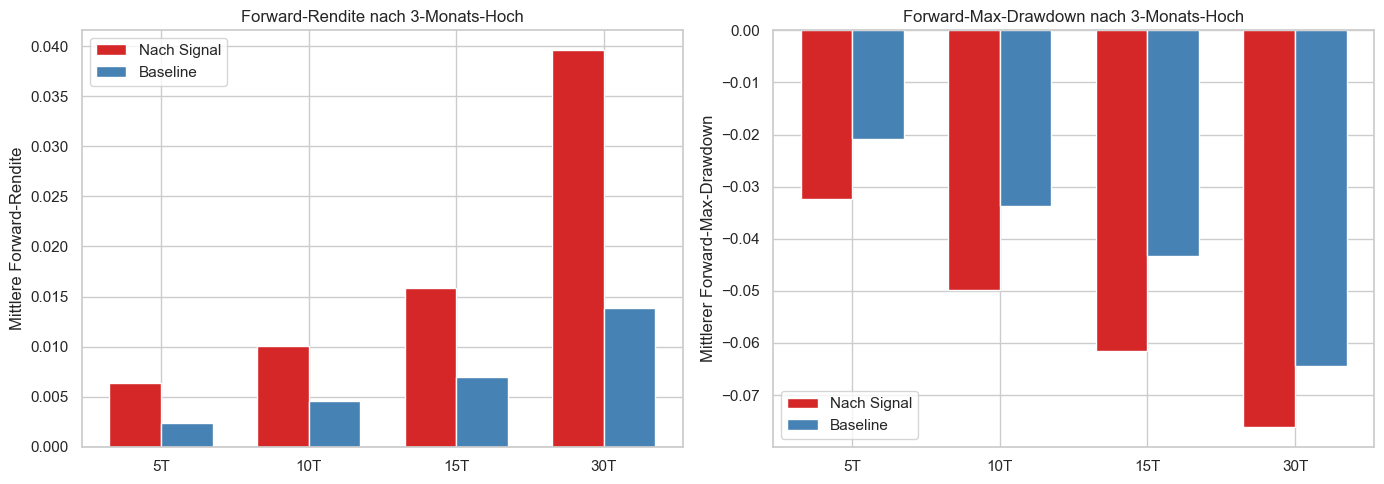

In [14]:
# Ergänzung: Forward-Rendite und Forward-Max-Drawdown des Russell 2000 nach dem
# 3-Monats-Hoch-Signal, plus Erweiterung der Trefferquote auf alle Horizonte.
zeilen_h6 = []
for h in HORIZONS:
    hr_sig = forward_hit_rate(new_3m_high, horizon=h)
    hr_base = forward_hit_rate(ALL_DAYS, horizon=h)
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(new_3m_high, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h6.append({
        "Horizont": f"{h}T",
        "Trefferq. Signal": hr_sig, "Trefferq. Baseline": hr_base,
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h6 = pd.DataFrame(zeilen_h6).set_index("Horizont")

disp_h6 = tab_h6.copy()
for spalte in ["Trefferq. Signal", "Trefferq. Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:.1%}")
for spalte in ["Rend. Signal", "Rend. Baseline", "MaxDD Signal", "MaxDD Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:+.2%}")
print(f"Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")
print(disp_h6.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h6["Rend. Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_r.bar(x + w/2, tab_h6["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Monats-Hoch")
ax_r.legend()
ax_d.bar(x - w/2, tab_h6["MaxDD Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_d.bar(x + w/2, tab_h6["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Monats-Hoch")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Über den Beobachtungszeitraum gab es 133 neue
3-Monats-Hochs. Nach einem solchen Signal lag der RVX in 33,1 %
(5 Tage) bzw. 36,1 % (10 Tage) der Fälle mindestens einmal über
34 – gegenüber einer Baseline von 12,1 % / 15,0 %.
Über die längeren Horizonte bleibt der Abstand bestehen (15/30 Tage:
37,6 % / 39,8 % gegenüber 17,5 % /
23,3 %). Das Signal erhöht die Trefferquote also robust, bleibt
aber ein Minderheits-Ereignis.

**Ergänzung – Forward-Kennzahlen des Russell 2000:** Wie in 4.1 markiert das Signal
erhöhtes Risiko, keine fallenden Kurse. Die mittlere Forward-Rendite nach dem
3-Monats-Hoch liegt über 30 Tage bei +3,96 % (über
Baseline +1,38 %), der Forward-Max-Drawdown fällt jedoch tiefer aus
(30 Tage: −7,61 % gegenüber −6,44 %). Das neue
3-Monats-Hoch kündigt somit vor allem eine turbulentere, im Mittel aber positiv
driftende Phase an.

**Praxisrelevanz für das Ampelsystem:** Ein neues 3-Monats-Hoch eignet sich als
zusätzliches „Vorsicht"-Flag, das bereits vor Erreichen der Rot-Schwelle
anschlägt – als kleines Warnsymbol neben der Hauptampel. Es warnt vor erhöhter
Schwankung und tieferen Rücksetzern, nicht vor einem Renditeeinbruch.

### 4.7 H7 – „3-Punkte-Umkehr“ als Beruhigungssignal

**Hypothese:** An Tagen mit Open ≥ 24 UND Intraday-High > Open UND
(Intraday-High − Close) ≥ 3 schießt der RVX im Tagesverlauf nach oben, gibt
den Anstieg bis Handelsschluss aber größtenteils wieder ab. Geprüft wird per
Event-Study, ob der RVX an den 5 Folgetagen im Schnitt fällt (= Beruhigung).


In [15]:
# Signal-Definition: ausgeprägte Intraday-Umkehr im RVX
#   - Open >= 24          -> Markt startet bereits angespannt (Gelb-Niveau)
#   - High > Open             -> im Tagesverlauf zieht der RVX weiter an
#   - (High - Close) >= 3     -> der Tag schließt aber mindestens 3 Punkte unter dem Hoch
rvx_ohlc = rvx[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (rvx_ohlc["Open"] >= RVX_THRESHOLD_GELB)
    & (rvx_ohlc["High"] > rvx_ohlc["Open"])
    & ((rvx_ohlc["High"] - rvx_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

HORIZON_H2 = 5
rvx_close_values = df["rvx_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue
    base = rvx_close_values.iloc[pos]
    path = rvx_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche RVX-Änderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median RVX-Änderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Fälle mit niedrigerem RVX nach {HORIZON_H2} Tagen: {share_falling:.1%}")


Anzahl '3-Punkte-Umkehr'-Signale: 150
Auswertbare Signale: 150
Durchschnittliche RVX-Änderung nach 5 Tagen: -1.53 Punkte
Median RVX-Änderung nach 5 Tagen:            -2.16 Punkte
Anteil Fälle mit niedrigerem RVX nach 5 Tagen: 70.7%


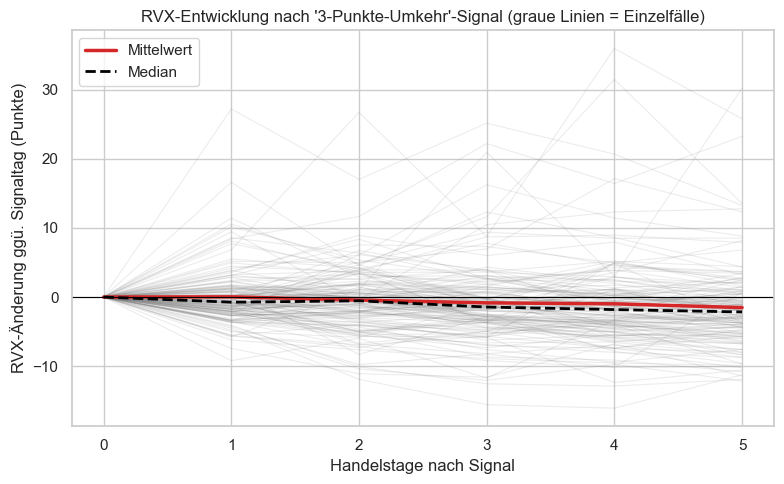

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("RVX-Änderung ggü. Signaltag (Punkte)")
ax.set_title("RVX-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfälle)")
ax.legend()
plt.tight_layout()
plt.show()

Auswertbare Signaltage: 150
         Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                        
5T             +0.54%         +0.23%       -3.79%         -2.09%
10T            +0.73%         +0.46%       -5.56%         -3.37%
15T            +1.74%         +0.70%       -6.54%         -4.32%
30T            +3.78%         +1.38%       -8.51%         -6.44%


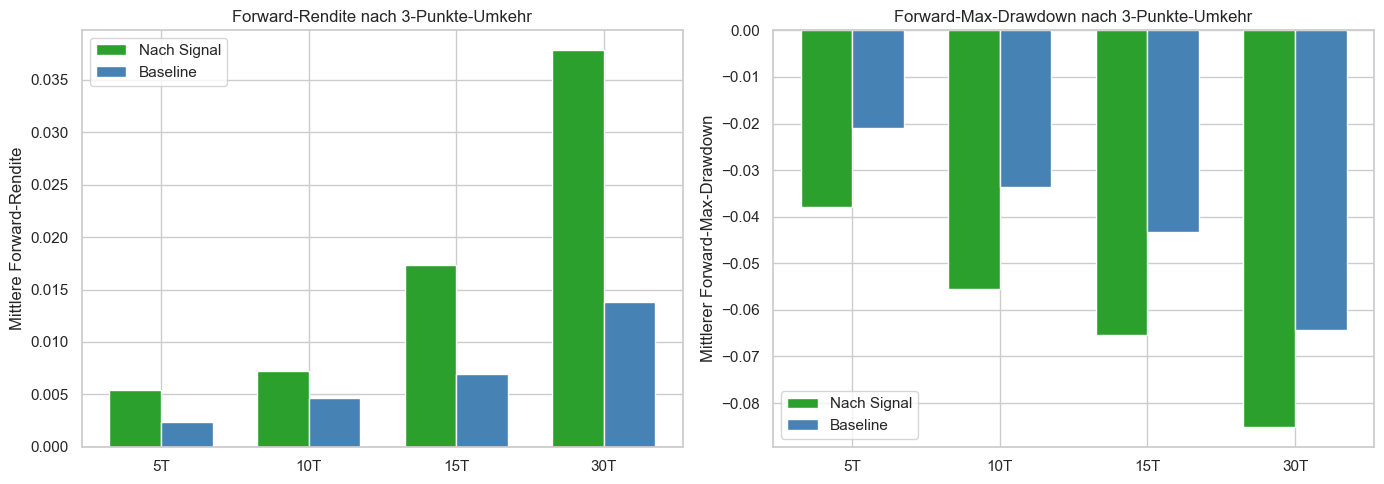

In [17]:
# Ergänzung: Das Umkehr-Signal wird zusätzlich als Renditesignalgeber für den
# Russell 2000 ausgewertet (Forward-Rendite und Forward-Max-Drawdown), im Vergleich
# zur Baseline. Die RVX-eigene Beruhigungs-Auswertung oben bleibt bestehen.
zeilen_h7 = []
for h in HORIZONS:
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(reversal_signal, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h7.append({
        "Horizont": f"{h}T",
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h7 = pd.DataFrame(zeilen_h7).set_index("Horizont")

disp_h7 = tab_h7.copy()
for spalte in disp_h7.columns:
    disp_h7[spalte] = tab_h7[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Signaltage: {n_sig}")
print(disp_h7.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h7["Rend. Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_r.bar(x + w/2, tab_h7["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Punkte-Umkehr")
ax_r.legend()
ax_d.bar(x - w/2, tab_h7["MaxDD Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_d.bar(x + w/2, tab_h7["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Punkte-Umkehr")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Von 150 „3-Punkte-Umkehr"-Signalen fiel der RVX
in 70,7 % der Fälle innerhalb von 5 Handelstagen unter den
Stand des Signaltags, im Schnitt um −1,53 Punkte (Median
−2,16). Die Beruhigungs-Hypothese wird tendenziell bestätigt
(rund zwei von drei Fällen), ist aber kein Automatismus.

**Ergänzung – der Russell 2000 als Renditesignal:** Wertet man das Signal als
Renditesignalgeber für den Index aus, liegt die Forward-Rendite über 30 Tage bei
+3,78 % und damit leicht über der Baseline (+1,38 %).
Der Pfad bleibt schwankungsanfällig – der Forward-Max-Drawdown ist mit
−8,51 % tiefer als die Baseline (−6,44 %). Die
RVX-Beruhigung ersetzt also kein aktives Risikomanagement.

**Praxisrelevanz für das Ampelsystem:** Das Signal eignet sich als
Entwarnungs-Hinweis innerhalb einer Gelb-/Rot-Phase („mögliche nahende
Beruhigung, historisch ca. 2 von 3 Fällen"), ohne einen neuen Ampelzustand zu
erzeugen.

### 4.8 H8 – RVX-Schwellenwerte anhand Verteilung und Stressphasen

**Hypothese:** Der RVX hebt sich während bekannter Stressphasen ab einem
bestimmten Niveau sichtbar vom Normalzustand ab. Verglichen werden die
Perzentile der Gesamtverteilung (50/75/90/95) mit Median, Minimum und Maximum
des RVX innerhalb und außerhalb der Krisenphasen, um die Gelb-/Rot-Schwellen
datenbasiert zu validieren.


In [18]:
percentiles_h3 = df["rvx_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("RVX-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nRVX während Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "rvx_close"].agg(["median", "min", "max"]).round(2))
print("\nRVX außerhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "rvx_close"].agg(["median", "min", "max"]).round(2))

RVX-Perzentile (gesamter Zeitraum):
0.50    22.11
0.75    26.85
0.90    33.24
0.95    37.97
Name: rvx_close, dtype: float64

RVX während Stressphasen (Median / Min / Max):
median    32.94
min       15.78
max       83.19
Name: rvx_close, dtype: float64

RVX außerhalb von Stressphasen (Median / Min / Max):
median    21.68
min       11.83
max       57.66
Name: rvx_close, dtype: float64


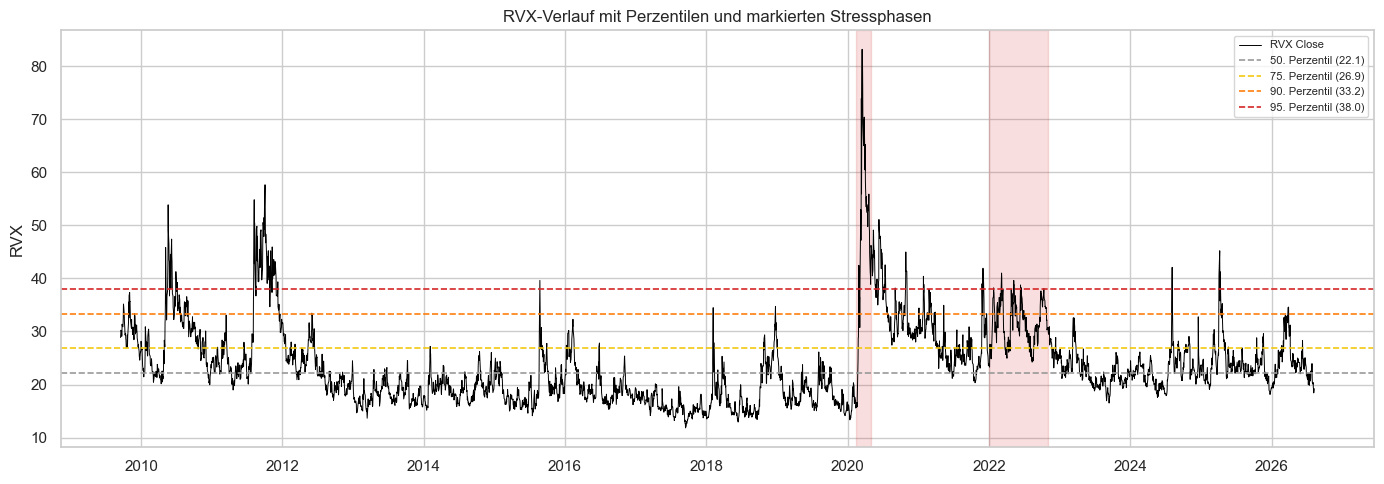

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["rvx_close"], color="black", linewidth=0.7, label="RVX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("RVX-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("RVX")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Der Median-RVX während der markierten Stressphasen
(32,9) liegt nahe am 90. Perzentil der Gesamtverteilung
(33,2) und deutlich über dem 75. Perzentil (26,9). Die
Rot-Schwelle 34 ist damit datenbasiert gut gedeckt, Gelb verortet sich im
Bereich 75.–90. Perzentil (ca. 27–33).
Dass der Maximalwert außerhalb der Phasen (57,7) hoch ist,
zeigt zugleich, dass die grob nach Kalenderdatum definierten Fenster nicht
trennscharf sind.

**Praxisrelevanz für das Ampelsystem:** Dieser Abschnitt belegt datenbasiert,
dass die RVX-Schwellen (Grün < 24, Gelb 24–34, Rot > 34) nicht
willkürlich sind, sondern sich an historischen Perzentilen und realem
Krisenverhalten orientieren.

### 4.9 H9 – Divergenz zum Index als Frühindikator

**Hypothese:** RVX und Russell 2000 sind normalerweise invers korreliert (vgl. 4.2).
Ein hoher Anteil an Tagen mit untypischem Gleichlauf (beide steigen gleichzeitig)
in einem rollierenden Fenster könnte nachfolgende Marktturbulenzen ankündigen.
Als Turbulenz-Definition dient konsistent zu 4.6: RVX > 34 in den nächsten
10 Handelstagen.


In [20]:
# Tage, an denen Russell 2000 UND RVX am selben Tag gleichzeitig gestiegen sind
co_up = (df["russell2000_return"] > 0) & (df["rvx_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: RVX > 34 in den nächsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(RVX > {RVX_THRESHOLD_ROT} in den nächsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(RVX > {RVX_THRESHOLD_ROT} in den nächsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 13 von 4241 (0.3%)
P(RVX > 34 in den nächsten 10 Tagen | Divergenz > 60%): 7.7%
P(RVX > 34 in den nächsten 10 Tagen), Baseline: 15.0%


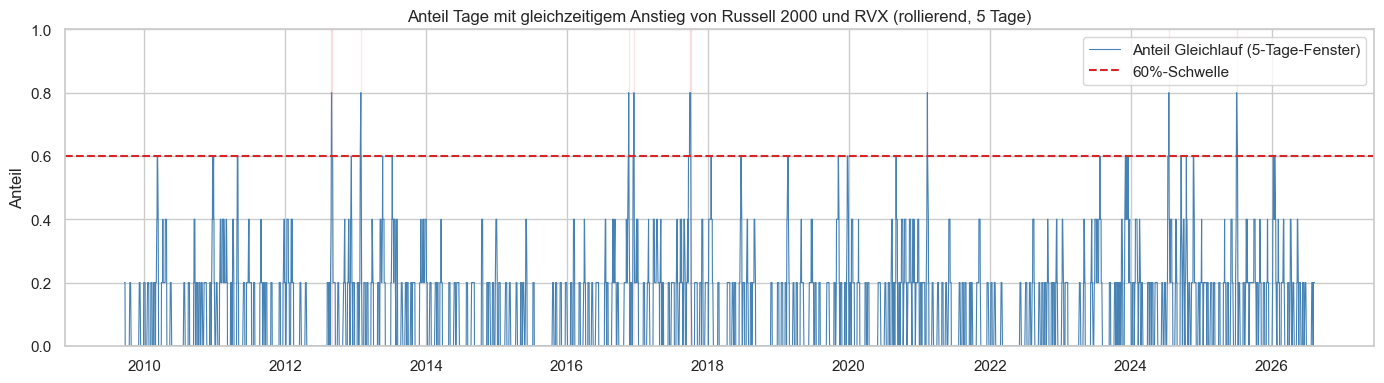

In [21]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von Russell 2000 und RVX (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von Russell 2000 und RVX an mindestens
60 % der Tage eines 5-Tage-Fensters ist mit 13 von 4241
Fenstern extrem selten. In dieser strengen Form ist die Stichprobe statistisch
nicht belastbar (Trefferquote 7,7 % vs. Baseline 15,0 %).

**Praxisrelevanz für das Ampelsystem:** Vor einer Aufnahme in die Ampel muss die
Definition gelockert und mit mehr Fällen getestet werden – genau das leistet die
folgende systematische Rasteranalyse.

**Fortsetzung – systematischer Parameterraster:** Die Original-Definition
(5-Tage-Fenster, 60 %-Schwelle) liefert nur wenige Signale und ist statistisch
nicht belastbar. Daher wird der Divergenz-Ansatz über einen vollständig
gekreuzten Parameterraster geprüft und zugleich um die beiden Russell 2000-Kennzahlen
**Forward-Rendite** und **Forward-Max-Drawdown** ergänzt:

- **Vorhersagehorizont:** 10, 15, 30 Handelstage
- **Beobachtungsfenster** (rollierender Divergenz-Anteil): 10, 15, 30 Tage
- **Anteils-Schwelle** (ab wann ein Fenster als Signal zählt): 15 %, 20 %, 25 %
- **Anstiegstag:** Russell 2000-Tagesrendite ≥ 0,25 % **und** gleichzeitig steigender
  RVX. Die Schwelle 0,25 % liegt bewusst knapp oberhalb des Rauschens der
  Tagesrendite und bezieht sich auf den **Index**, nicht auf die RVX-Veränderung.

Das ergibt 3 × 3 × 3 = **27 Kombinationen**. Als Mindestkriterium für eine
belastbare Aussage (und damit für eine eigene Visualisierung) gelten
**mindestens 30 Signaltage**. Alle 27 Kombinationen erscheinen vollständig in
der Ergebnistabelle; separat visualisiert werden nur die belastbaren.


In [22]:
# Anstiegstag = Index-Tagesrendite >= 0,25 % UND gleichzeitig steigender RVX.
# (russell2000_return liegt in %, daher Schwelle 0.25; die Signifikanzschwelle bezieht
#  sich damit korrekt auf den Index und nicht auf die RVX-Veränderung.)
co_up_div = (df["russell2000_return"] >= 0.25) & (df["rvx_change"] > 0)

RASTER_HORIZONTE = [10, 15, 30]
RASTER_FENSTER = [10, 15, 30]
RASTER_LEVELS = [0.15, 0.20, 0.25]
MIN_SIGNALE = 30  # Mindestkriterium für Belastbarkeit und eigene Visualisierung

raster_zeilen = []
for fenster in RASTER_FENSTER:
    for level in RASTER_LEVELS:
        signal = co_up_div.rolling(fenster).mean() > level
        n_signale = int(signal.sum())
        for horizont in RASTER_HORIZONTE:
            hr = forward_hit_rate(signal, horizon=horizont)
            hr_base = forward_hit_rate(ALL_DAYS, horizon=horizont)
            fr, mdd, _ = forward_kennzahlen(signal, horizont)
            fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, horizont)
            raster_zeilen.append({
                "Fenster": fenster, "Schwelle": level, "Horizont": horizont,
                "Signale": n_signale,
                "Trefferquote": hr, "Trefferq_Baseline": hr_base,
                "Fwd_Rendite": fr, "Rendite_Baseline": fr_base,
                "Fwd_MaxDD": mdd, "MaxDD_Baseline": mdd_base,
                "belastbar": n_signale >= MIN_SIGNALE,
            })
raster = pd.DataFrame(raster_zeilen)
print(f"Kombinationen gesamt: {len(raster)} | "
      f"davon belastbar (>= {MIN_SIGNALE} Signale): {int(raster['belastbar'].sum())}")

disp_raster = pd.DataFrame({
    "Fenster": raster["Fenster"].astype(int).map(lambda x: f"{x}T"),
    "Schwelle": raster["Schwelle"].map(lambda x: f"{x:.0%}"),
    "Horizont": raster["Horizont"].astype(int).map(lambda x: f"{x}T"),
    "Signale": raster["Signale"].astype(int),
    "Trefferq.": raster["Trefferquote"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "n/a"),
    "Baseline": raster["Trefferq_Baseline"].map(lambda x: f"{x:.1%}"),
    "Fwd-Rend.": raster["Fwd_Rendite"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "Rend-Base": raster["Rendite_Baseline"].map(lambda x: f"{x:+.2%}"),
    "Fwd-MaxDD": raster["Fwd_MaxDD"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "MaxDD-Base": raster["MaxDD_Baseline"].map(lambda x: f"{x:+.2%}"),
    "belastbar": raster["belastbar"].map(lambda x: "ja" if x else "nein"),
})
print(disp_raster.to_string(index=False))


Kombinationen gesamt: 27 | davon belastbar (>= 30 Signale): 27
Fenster Schwelle Horizont  Signale Trefferq. Baseline Fwd-Rend. Rend-Base Fwd-MaxDD MaxDD-Base belastbar
    10T      15%      10T      740     11.4%    15.0%    +0.37%    +0.46%    -3.07%     -3.37%        ja
    10T      15%      15T      740     15.7%    17.5%    +0.62%    +0.70%    -4.00%     -4.32%        ja
    10T      15%      30T      740     23.2%    23.3%    +1.42%    +1.38%    -6.04%     -6.44%        ja
    10T      20%      10T      233     15.9%    15.0%    +0.31%    +0.46%    -3.14%     -3.37%        ja
    10T      20%      15T      233     21.5%    17.5%    +0.34%    +0.70%    -4.24%     -4.32%        ja
    10T      20%      30T      233     27.5%    23.3%    +0.96%    +1.38%    -6.03%     -6.44%        ja
    10T      25%      10T      233     15.9%    15.0%    +0.31%    +0.46%    -3.14%     -3.37%        ja
    10T      25%      15T      233     21.5%    17.5%    +0.34%    +0.70%    -4.24%     -4.32%   

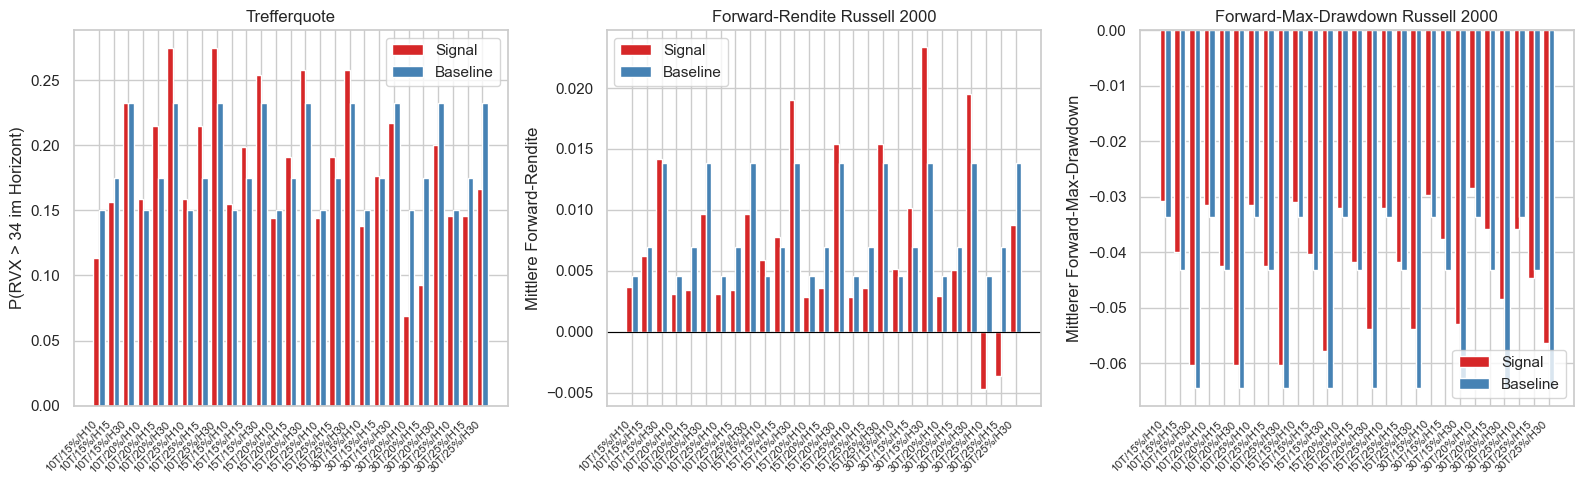

In [23]:
# Visualisierung nur für belastbare Kombinationen (>= MIN_SIGNALE Signale).
relevant = raster[raster["belastbar"]].copy()
if relevant.empty:
    print("Keine Kombination erreicht das Mindestkriterium - keine Visualisierung.")
else:
    relevant["label"] = (
        relevant["Fenster"].astype(int).astype(str) + "T/"
        + (relevant["Schwelle"] * 100).round().astype(int).astype(str) + "%/H"
        + relevant["Horizont"].astype(int).astype(str)
    )
    x = np.arange(len(relevant)); w = 0.38
    fig, (ax_t, ax_r, ax_d) = plt.subplots(1, 3, figsize=(16, 5))

    ax_t.bar(x - w/2, relevant["Trefferquote"], w, color=COLOR_RED, label="Signal")
    ax_t.bar(x + w/2, relevant["Trefferq_Baseline"], w, color="steelblue", label="Baseline")
    ax_t.set_ylabel("P(RVX > 34 im Horizont)")
    ax_t.set_title("Trefferquote")

    ax_r.bar(x - w/2, relevant["Fwd_Rendite"], w, color=COLOR_RED, label="Signal")
    ax_r.bar(x + w/2, relevant["Rendite_Baseline"], w, color="steelblue", label="Baseline")
    ax_r.axhline(0, color="black", linewidth=0.8)
    ax_r.set_ylabel("Mittlere Forward-Rendite")
    ax_r.set_title("Forward-Rendite Russell 2000")

    ax_d.bar(x - w/2, relevant["Fwd_MaxDD"], w, color=COLOR_RED, label="Signal")
    ax_d.bar(x + w/2, relevant["MaxDD_Baseline"], w, color="steelblue", label="Baseline")
    ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
    ax_d.set_title("Forward-Max-Drawdown Russell 2000")

    for ax in (ax_t, ax_r, ax_d):
        ax.set_xticks(x)
        ax.set_xticklabels(relevant["label"], rotation=45, ha="right", fontsize=8)
        ax.legend()
    plt.tight_layout(); plt.show()


**Ergebnis der Rasteranalyse:** Von den 27 Kombinationen erfüllen 27 das
Mindestkriterium von 30 Signaltagen. Eine niedrige Schwelle (15 %)
erzeugt viele, aber unspezifische Signale; höhere Schwellen (20–25 %) heben die
Turbulenz-Wahrscheinlichkeit deutlicher. Die trennschärfste belastbare Kombination
ist 10-Tage-Fenster/20 % (Horizont 30 Tage):
Trefferquote 27,5 % gegenüber 23,3 % Baseline.

Der entscheidende Unterschied zu den übrigen Signalen liegt in der
**Renditerichtung**: Die trennschärfsten Divergenz-Varianten sind die einzigen
Signale mit einer *unterdurchschnittlichen* Forward-Rendite des Russell 2000 (z. B.
30-Tage-Fenster/25 %, Horizont 10 Tage:
−0,47 % gegenüber +0,46 % Baseline). Während 3-Monats-Hoch
(4.6) und 3-Punkte-Umkehr (4.7) überdurchschnittliche Folgerenditen aufweisen und
damit reine *Volatilitätsflags* sind, trägt die Divergenz zusätzlich eine – wenn
auch schwache – *richtungsweisende* (leicht bearishe) Information.

**Praxisrelevanz für das Ampelsystem:** Die Divergenz kommt als langsames,
ergänzendes Warnsignal in Frage, das als einziges nicht nur erhöhte Schwankung,
sondern auch eine leicht negative Renditeerwartung anzeigt. Wegen der geringen
Effektstärke eignet sie sich als Zusatz-Indikator, nicht als eigenständiger
Ampel-Auslöser.

## 5. Vertiefte Einzelbetrachtung

Die Hypothesenanalyse in Abschnitt 4 bewertet jedes Signal für sich. Dieser
Abschnitt hat einen gezielten, davon verschiedenen Zweck: Er **stellt die
ampel-relevanten Signale direkt gegenüber**, um ihre *Charakteristik* zu
vergleichen – insbesondere die Frage, welche Signale dem RVX-Anstieg
**vorlaufen** und welche eher **gleichlaufend** auf bereits erhöhtem Niveau
auftreten. Diese Unterscheidung ergibt sich erst aus der einheitlichen
Betrachtung mehrerer Signale mit demselben Kennzahlensatz und ist der eigentliche
Mehrwert dieses Abschnitts gegenüber der Einzelauswertung in Kapitel 4.

**Darstellung und methodische Abgrenzung:** Analog zur „Vertieften
Einzelbetrachtung“ (7.4) des SMA-Schwester-Notebooks wird je Signal eine
zweiteilige Grafik erstellt: oben der RVX-Verlauf mit farblich hinterlegten
Signaltagen, unten das **Vorwärts-Profil** (Event-Study) – der gemittelte Pfad
der RVX-Änderung in den Handelstagen nach dem Signal. Da dieses Notebook
explorativ ist und keine handelbare Strategie backtestet, tritt das
Vorwärts-Profil an die Stelle der Equity-Kurve des Referenz-Notebooks. Die
verwendeten Kennzahlen-Entsprechungen:

| SMA-Notebook (7.4) | RVX-Entsprechung | Begründung |
|---|---|---|
| Anteil ausgeschlossener Tage | Anteil Handelstage mit Signal | Beides misst die Häufigkeit des markierten Zustands. |
| Gesamtrendite / CAGR | Mittl. RVX-Änderung nach 5 / 10 Tagen | Typisches Ergebnis nach dem Signal: Beruhigung (fallend) vs. Eskalation (steigend). |
| Max Drawdown | Median max. RVX-Anstieg im Folgefenster | Beim RVX ist das Risiko ein Aufwärts-Ausschlag. |
| (Signalgüte) | Trefferquote RVX > 34 vs. Baseline | Prognostischer Mehrwert (vgl. 3.1). |

**Auswahl der Signale:** Verglichen werden drei Signale mit unterschiedlicher
Charakteristik: das **neue 3-Monats-Hoch** (H6), die **Divergenz Block 6** (H9)
sowie das **Rot-Regime** (RVX ≥ 34) als Basis-Ampelzustand. Die *3-Punkte-Umkehr*
(H7) wird hier nicht erneut einzeln dargestellt, da ihr Vorwärts-Verhalten
bereits in Abschnitt 4.7 als eigene Event-Study analysiert wurde; in der
Gesamteinordnung unten wird sie dennoch berücksichtigt.


### 5.1 Vorbereitung: Signal-Katalog und Hilfsfunktionen

Zunächst werden die vier Signalmasken einheitlich auf dem gemeinsamen
Handelskalender definiert (konsistent zu den Definitionen aus Abschnitt 4)
sowie zwei zusätzliche Plot-Farben ergänzt. Die Funktion
`vertiefte_einzelbetrachtung` kapselt die zweiteilige Darstellung und die
Kennzahlen-Berechnung.


In [24]:
# --- Zusätzliche Plot-Farben für die 2-Panel-Darstellung
COLOR_PRICE = "#0b0b0b"   # RVX-Kurve (neutral/dunkel)
COLOR_MUTED = "#898781"   # Einzelpfade im Vorwärtsprofil

# --- Signal-Katalog: die vier repräsentativen Signale aus Kapitel 4 ----------
# Signal 1: Neues 3-Monats-Hoch (vgl. 4.6) - höchster Schlusskurs der letzten 63 Tage
sig_3m_hoch = df["rvx_close"] > df["rvx_close"].shift(1).rolling(63).max()

# Signal 2: 3-Punkte-Umkehr (vgl. 4.7) - Intraday-Hochschuss mit Rücksetzer zum Close
_ohlc = rvx[["Open", "High", "Low", "Close"]].reindex(df.index)
sig_umkehr = (
    (_ohlc["Open"] >= RVX_THRESHOLD_GELB)
    & (_ohlc["High"] > _ohlc["Open"])
    & ((_ohlc["High"] - _ohlc["Close"]) >= 3)
)

# Signal 3: Divergenz-Variante Block 6 (vgl. 4.9) - 20-Tage-Fenster, 20 %-Schwelle,
#           Index-Anstieg >= 0,25 %
_co_up = (df["russell2000_return"] > 0.25) & (df["rvx_change"] > 0)
sig_divergenz = _co_up.rolling(20).mean() > 0.20

# Signal 4: Rot-Regime (RVX >= 34, vgl. 4.4/4.5) - der Basis-Ampelzustand.
sig_rot = df["rvx_close"] >= RVX_THRESHOLD_ROT
sig_rot_eintritt = sig_rot & ~sig_rot.shift(1, fill_value=False)

print("Signal-Katalog erstellt:")
for _name, _maske in [("3-Monats-Hoch", sig_3m_hoch), ("3-Punkte-Umkehr", sig_umkehr),
                      ("Divergenz (Block 6)", sig_divergenz), ("Rot-Regime", sig_rot),
                      ("Rot-Eintritte", sig_rot_eintritt)]:
    print(f"  {_name:22s}: {int(_maske.sum()):4d} Tage")


Signal-Katalog erstellt:
  3-Monats-Hoch         :  133 Tage
  3-Punkte-Umkehr       :  150 Tage
  Divergenz (Block 6)   :  171 Tage
  Rot-Regime            :  385 Tage
  Rot-Eintritte         :   45 Tage


In [25]:
def vertiefte_einzelbetrachtung(name, phasen_maske, ereignis_maske=None,
                                horizon=10, titel=None, farbe=COLOR_RED):
    '''Zweiteilige Einzelbetrachtung eines Signals (analog zur SMA-Notebook-
    Systematik): oben der RVX-Verlauf mit farblich hinterlegten Signaltagen,
    darunter das gemittelte Vorwärtsprofil des RVX in den Tagen nach dem Signal
    (Event-Study). Gibt die Kennzahlen als dict zurück.'''
    titel = titel or name
    phasen = phasen_maske.reindex(df.index).fillna(False)
    ereignis = ereignis_maske if ereignis_maske is not None else phasen_maske
    ereignis = ereignis.reindex(df.index).fillna(False)

    rvx_werte = df["rvx_close"].values
    ereignis_idx = np.where(ereignis.values)[0]

    # Vorwärtsprofile relativ zum Signaltag + abgeleitete Kennzahlen
    pfade, max_anstiege = [], []
    treffer, gueltig = 0, 0
    for i in ereignis_idx:
        if i + horizon >= len(rvx_werte):
            continue  # kein vollständiges Folgefenster mehr vorhanden
        basis = rvx_werte[i]
        pfade.append(rvx_werte[i : i + horizon + 1] - basis)
        nachfolger = rvx_werte[i + 1 : i + 1 + horizon]
        gueltig += 1
        if nachfolger.max() > RVX_THRESHOLD_ROT:
            treffer += 1
        max_anstiege.append(nachfolger.max() - basis)
    pfade = np.array(pfade)
    mittel_pfad = pfade.mean(axis=0)
    median_pfad = np.median(pfade, axis=0)

    anteil_tage = phasen.mean()
    trefferquote = treffer / gueltig if gueltig else np.nan
    aenderung_5 = mittel_pfad[5] if horizon >= 5 else np.nan
    aenderung_10 = mittel_pfad[horizon]
    median_max_anstieg = float(np.median(max_anstiege)) if max_anstiege else np.nan

    # --- 2-Panel-Plot: oben RVX + Signalphasen, unten Vorwärtsprofil
    fig, (ax_vix, ax_fwd) = plt.subplots(2, 1, figsize=(12, 7))

    ax_vix.fill_between(df.index, 0, 1, where=phasen.values, color=farbe, alpha=0.15,
                        transform=ax_vix.get_xaxis_transform())
    ax_vix.plot(df.index, df["rvx_close"], color=COLOR_PRICE, linewidth=0.8)
    ax_vix.axhline(RVX_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
                   label=f"Rot-Schwelle ({RVX_THRESHOLD_ROT})")
    ax_vix.set_ylabel("RVX")
    ax_vix.set_title(f"{titel} – farblich hinterlegt: Signaltage")
    ax_vix.legend(loc="upper right")

    tage = np.arange(0, horizon + 1)
    for p in pfade:
        ax_fwd.plot(tage, p, color=COLOR_MUTED, alpha=0.12, linewidth=0.7)
    ax_fwd.plot(tage, mittel_pfad, color=farbe, linewidth=2.5, label="Mittelwert")
    ax_fwd.plot(tage, median_pfad, color="black", linewidth=2, linestyle="--", label="Median")
    ax_fwd.axhline(0, color="black", linewidth=0.8)
    ax_fwd.set_xlabel("Handelstage nach Signal")
    ax_fwd.set_ylabel("RVX-Änderung ggü. Signaltag (Punkte)")
    ax_fwd.set_title("Gemitteltes Vorwärtsprofil (graue Linien = Einzelfälle)")
    ax_fwd.legend(loc="upper left")

    fig.tight_layout()
    plt.show()

    print(f"Anteil Handelstage mit Signal:             {anteil_tage:.1%}  ({int(phasen.sum())} Tage)")
    print(f"Auswertbare Ereignisse (Vorwärtsprofil):   {gueltig}")
    print(f"Trefferquote RVX > {RVX_THRESHOLD_ROT} in {horizon} Tagen:         {trefferquote:.1%}  (Baseline: {baseline_10:.1%})")
    print(f"Mittl. RVX-Änderung nach 5 / {horizon} Tagen:     {aenderung_5:+.2f} / {aenderung_10:+.2f} Punkte")
    print(f"Median max. RVX-Anstieg im {horizon}-Tage-Fenster:  {median_max_anstieg:+.2f} Punkte")

    return {"name": name, "anteil_tage": anteil_tage, "trefferquote": trefferquote,
            "aenderung_5": aenderung_5, "aenderung_10": aenderung_10,
            "median_max_anstieg": median_max_anstieg, "n_ereignisse": gueltig}


### 5.2 Einzelbetrachtung der repräsentativen Signale

Für jedes Signal folgen die zweiteilige Grafik, die Kennzahlen sowie eine
kurze Ergebnis- und Praxiseinordnung.


#### Signal 1 – Neues 3-Monats-Hoch (H6)


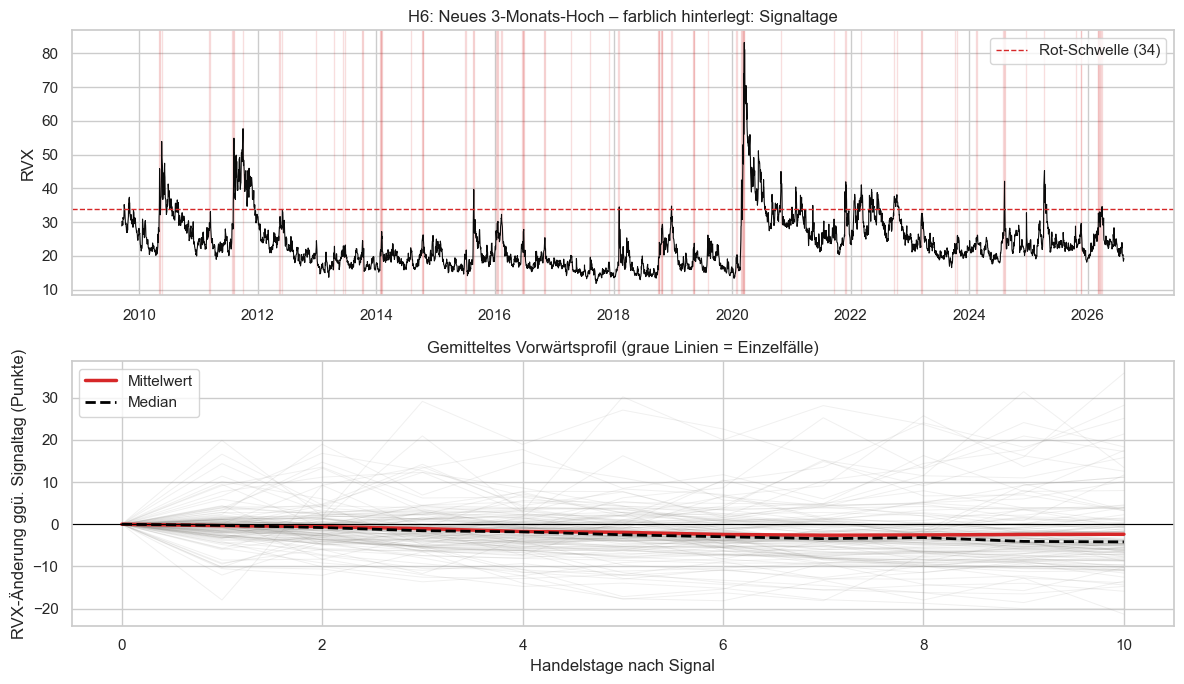

Anteil Handelstage mit Signal:             3.1%  (133 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   133
Trefferquote RVX > 34 in 10 Tagen:         36.1%  (Baseline: 15.0%)
Mittl. RVX-Änderung nach 5 / 10 Tagen:     -1.92 / -2.37 Punkte
Median max. RVX-Anstieg im 10-Tage-Fenster:  +1.17 Punkte


In [26]:
res_3m = vertiefte_einzelbetrachtung(
    "3-Monats-Hoch", sig_3m_hoch, titel="H6: Neues 3-Monats-Hoch", farbe=COLOR_RED)


**Ergebnis:** Das Signal markiert 3,1 % der Handelstage
(133 Ereignisse). Die Trefferquote für RVX > 34 innerhalb von 10 Tagen
liegt mit 36,1 % über der
Baseline (15,0 %). Im Mittel *fällt* der RVX nach dem Signal jedoch
(−1,92 nach 5, −2,37 nach 10 Tagen), und der mediane maximale
Weiter-Anstieg ist mit +1,17 Punkten gering – ein neues
3-Monats-Hoch tritt oft bereits auf erhöhtem Niveau auf, das anschließend eher
mean-revertiert.

**Praxisrelevanz für das Ampelsystem:** Das Signal taugt als Frühwarn-Flag für
eine erhöhte Rot-Bereitschaft, nicht als Vorbote einer weiteren Eskalation –
passend zur Rolle als dezentes „Vorsicht"-Nebensignal neben der Hauptampel.

#### Signal 2 – Divergenz (Block 6, H9)


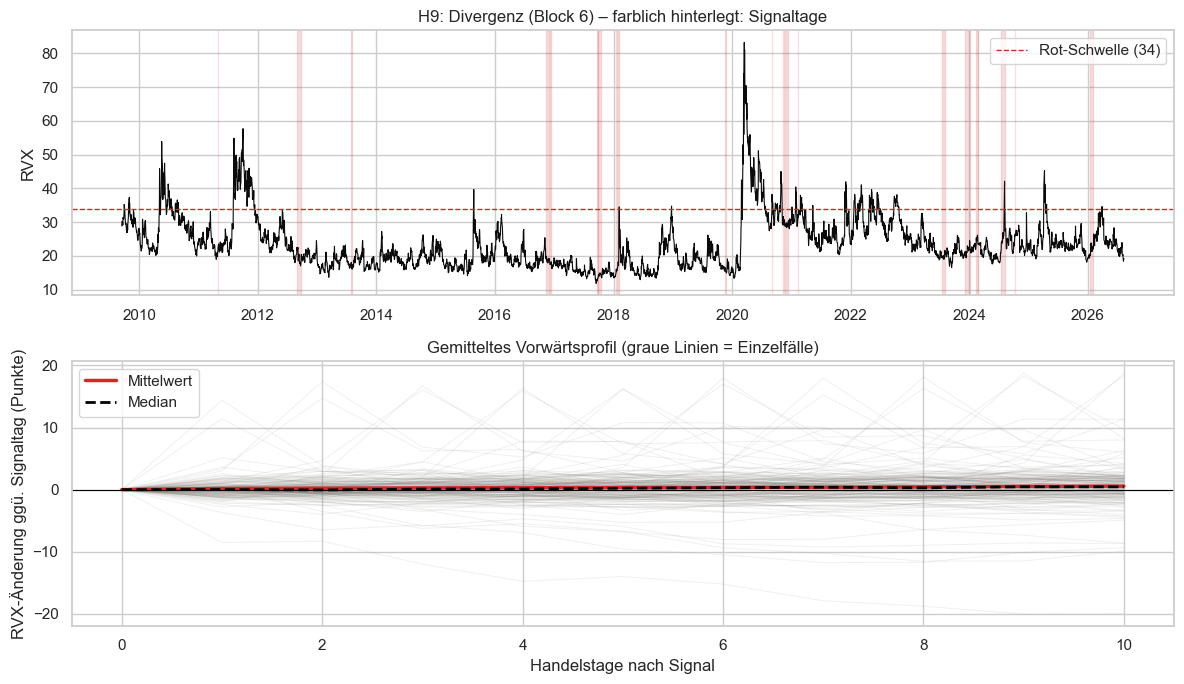

Anteil Handelstage mit Signal:             4.0%  (171 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   171
Trefferquote RVX > 34 in 10 Tagen:         14.0%  (Baseline: 15.0%)
Mittl. RVX-Änderung nach 5 / 10 Tagen:     +0.35 / +0.57 Punkte
Median max. RVX-Anstieg im 10-Tage-Fenster:  +1.77 Punkte


In [27]:
res_div = vertiefte_einzelbetrachtung(
    "Divergenz (Block 6)", sig_divergenz, titel="H9: Divergenz (Block 6)", farbe=COLOR_RED)


**Ergebnis:** Dieses Signal verhält sich als einziges qualitativ anders: Sein
Vorwärtsprofil *steigt* (+0,35 nach 5, +0,57 nach 10 Tagen),
und der mediane maximale Anstieg ist mit +1,77 Punkten der größte aller
Signale. Die Trefferquote liegt mit 14,0 %
unter der Baseline (15,0 %). Bei
4,0 % der Tage (171 Ereignisse) markiert es eine Phase *vor* dem
Anstieg.

**Praxisrelevanz für das Ampelsystem:** Anders als die übrigen Signale, die auf
bereits erhöhtem Niveau auftreten und mean-revertieren, ist die Divergenz Block 6
der einzige *vorlaufende* Kandidat im Katalog – er kann anschlagen, bevor die
Hauptampel auf Rot springt (bei allerdings schmaler Datenbasis).

#### Signal 3 – Rot-Regime (RVX ≥ 34)


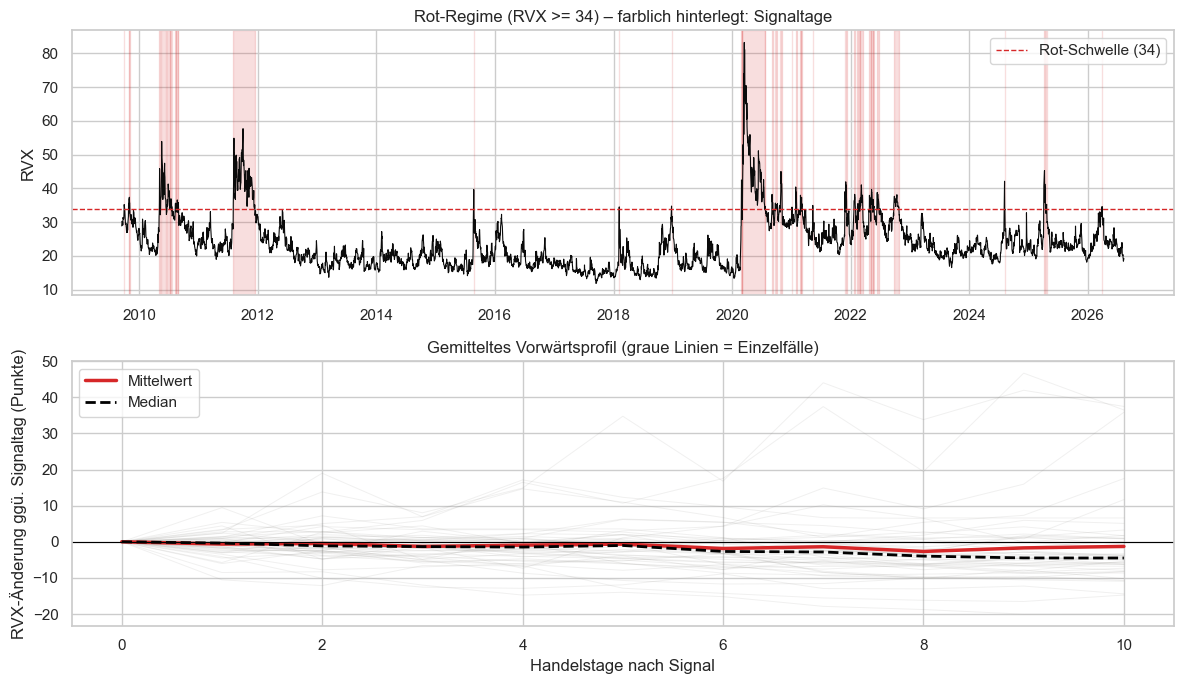

Anteil Handelstage mit Signal:             9.1%  (385 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   45
Trefferquote RVX > 34 in 10 Tagen:         82.2%  (Baseline: 15.0%)
Mittl. RVX-Änderung nach 5 / 10 Tagen:     -0.64 / -1.28 Punkte
Median max. RVX-Anstieg im 10-Tage-Fenster:  +1.49 Punkte


In [28]:
res_rot = vertiefte_einzelbetrachtung(
    "Rot-Regime", sig_rot, ereignis_maske=sig_rot_eintritt,
    titel="Rot-Regime (RVX >= 34)", farbe=COLOR_RED)


**Ergebnis:** Der RVX ist an 9,1 % der Tage im Rot-Bereich;
ausgewertet werden die 45 Eintrittsereignisse. Erwartungsgemäß ist die
Trefferquote trivial hoch (82,2 %), da der RVX beim Eintritt
bereits nahe 34 liegt. Das Vorwärtsprofil fällt danach im Mittel deutlich
(−0,64 / −1,28), ein großer weiterer Anstieg ist selten
(medianer max. Anstieg nur +1,49).

**Praxisrelevanz für das Ampelsystem:** Ein Rot-Eintritt ist meist ein kurzer
Ausschlag mit anschließender Beruhigung, kein Auftakt zu immer weiter steigender
Panik. Das stützt die Empfehlung, einen einzelnen Rot-Tag nicht zu überzeichnen
und erst bei mehrtägiger Persistenz zu eskalieren.

### 5.3 Konsolidierte Übersicht und Einordnung

Gegenüberstellung der vier Signale anhand der RVX-spezifischen Kennzahlen.


In [29]:
uebersicht = pd.DataFrame([res_3m, res_div, res_rot]).set_index("name")
uebersicht_anzeige = pd.DataFrame({
    "Anteil Tage": uebersicht["anteil_tage"].map(lambda x: f"{x:.1%}"),
    "Ereignisse": uebersicht["n_ereignisse"].astype(int),
    "Trefferquote (RVX>34/10T)": uebersicht["trefferquote"].map(lambda x: f"{x:.1%}"),
    "RVX-Änderung 5T": uebersicht["aenderung_5"].map(lambda x: f"{x:+.2f}"),
    "RVX-Änderung 10T": uebersicht["aenderung_10"].map(lambda x: f"{x:+.2f}"),
    "Median max. Anstieg 10T": uebersicht["median_max_anstieg"].map(lambda x: f"{x:+.2f}"),
})
uebersicht_anzeige.insert(0, "Baseline (RVX>34/10T)", f"{baseline_10:.1%}")
print(uebersicht_anzeige.to_string())


                    Baseline (RVX>34/10T) Anteil Tage  Ereignisse Trefferquote (RVX>34/10T) RVX-Änderung 5T RVX-Änderung 10T Median max. Anstieg 10T
name                                                                                                                                                
3-Monats-Hoch                       15.0%        3.1%         133                     36.1%           -1.92            -2.37                   +1.17
Divergenz (Block 6)                 15.0%        4.0%         171                     14.0%           +0.35            +0.57                   +1.77
Rot-Regime                          15.0%        9.1%          45                     82.2%           -0.64            -1.28                   +1.49


**Zusammenfassende Einordnung:** Die Signale zerfallen in zwei
Charakteristiken. **Gleichlaufende/beruhigende Signale** treten auf bereits
erhöhtem RVX-Niveau auf und zeigen ein im Mittel *fallendes* Vorwärtsprofil: das
3-Monats-Hoch (−2,37 nach 10 Tagen), der Rot-Eintritt (−1,28)
und – in Abschnitt 4.7 gezeigt – die 3-Punkte-Umkehr (−1,79). Sie
beschreiben den *aktuellen* Zustand. Demgegenüber ist die **Divergenz Block 6** das
einzige Signal mit *steigtdem* Vorwärtsprofil (+0,57) und dem größten
medianen Folge-Anstieg (+1,77) – und damit der einzige echte
*vorlaufende* Frühindikator-Kandidat im Katalog (bei noch schmaler Datenbasis von
171 Fällen). Alle Kennzahlen sind explorativ und beschreiben historische
Durchschnitte, keine garantierten Prognosen.

## 6. Was-wäre-wenn-Analyse: Wirkung des RVX-gestützten Risikoausschlusses

Die bisherigen Abschnitte beschreiben den Marktzustand. Dieser Abschnitt nimmt
die Perspektive einer Anlegerin ein und beantwortet die Frage direkt: **Wie
hätte sich die Wertentwicklung des Russell 2000 unterschieden, wenn man an den vom
RVX als riskant eingestuften Tagen nicht investiert gewesen wäre?** Dazu wird
die Wertentwicklung von **Buy & Hold** (durchgehend im Russell 2000 investiert) einer
**Ausschluss-Strategie** gegenübergestellt, die an RVX-Risikotagen in Cash geht.

**Methodische Abgrenzung:** Das RVX-Signal ist am jeweiligen Handelsschluss
bekannt und wird um einen Tag verschoben angewendet (Entscheidung am
Vortagsschluss → die Strategie ist frei von Rückschaufehlern/Look-ahead-Bias).
An ausgeschlossenen Tagen beträgt die Tagesrendite 0 %. Vereinfachend werden
**Transaktionskosten und eine Verzinsung der Cash-Position nicht** berücksichtigt.
Die Ergebnisse zeigen daher das **theoretische Potenzial** einer RVX-gestützten
Risikosteuerung, nicht die realistisch erzielbare Rendite einer handelbaren Strategie.

**Wichtiger Vorbehalt zum RVX:** Hohe RVX-Werte markieren historisch nicht nur
Abschwünge, sondern fallen oft mit dem Tiefpunkt und der anschließenden,
besonders kräftigen Erholung zusammen. Ein Ausschluss von Hoch-RVX-Tagen
vermeidet daher zwar Verlusttage, kann aber auch starke Erholungstage verpassen –
dieser Zielkonflikt ist bei der Interpretation der Renditen zentral.


### 6.1 Backtest-Hilfsfunktionen

`was_waere_wenn` berechnet für eine gegebene Risikomaske die Wertentwicklung
beider Varianten sowie Gesamtrendite, annualisierte Rendite (CAGR) und den
historischen maximalen Drawdown.


In [30]:
def historischer_max_drawdown(werte):
    # Klassischer Peak-to-Trough-Drawdown einer kumulierten Wertreihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(risiko_maske, label):
    '''Simuliert eine Strategie, die an RVX-Risikotagen in Cash geht (Tagesrendite 0,
    ohne Cash-Verzinsung und Transaktionskosten) und sonst voll im Russell 2000 investiert
    ist. Das RVX-Signal wird um einen Tag verschoben angewendet (Entscheidung am
    Vortagsschluss -> kein Look-ahead-Bias). Vergleich mit Buy & Hold.'''
    tagesrendite = df["russell2000_close"].pct_change().fillna(0)
    risiko = risiko_maske.reindex(df.index).fillna(False).shift(1, fill_value=False)

    strategie_rendite = tagesrendite.where(~risiko, 0.0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity):
        gesamt = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamt, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "risikophase": label,
        "anteil_risikotage": risiko.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 6.2 RVX-Risikophasen-Definitionen

Aus den Erkenntnissen der Kapitel 4 und 5 werden fünf Risikophasen abgeleitet.
Für die ereignisbasierten Signale (3-Monats-Hoch, Divergenz Block 6) gilt das
Risiko am Signaltag und den darauf folgenden 9 Handelstagen (10-Tage-Fenster,
konsistent zur Turbulenz-Definition aus Abschnitt 4.6):

- **Rot (RVX ≥ 34)** – der Ausnahmezustand der Ampel.
- **Gelb+Rot (RVX ≥ 24)** – alle angespannten und schlimmeren Tage.
- **3-Monats-Hoch (+10 Tage)** – Frühwarnfenster nach einem neuen 3-Monats-Hoch (H6).
- **Divergenz Block 6 (+10 Tage)** – Fenster nach dem vorlaufenden Divergenzsignal (H9).
- **Kombiniert (Rot oder Block 6)** – Rot-Zustand ODER laufendes Block-6-Frühwarnfenster.


In [31]:
# Nachlauf-Fenster: Risiko gilt am Signaltag und den folgenden k-1 Handelstagen
def nachlauf(signal, k=10):
    maske = signal.reindex(df.index).fillna(False)
    return maske.rolling(k, min_periods=1).max().astype(bool)

_sig_3m_hoch = df["rvx_close"] > df["rvx_close"].shift(1).rolling(63).max()
_co_up = (df["russell2000_return"] > 0.25) & (df["rvx_change"] > 0)
_sig_divergenz = _co_up.rolling(20).mean() > 0.20

risiko_definitionen = {
    "Rot (RVX >= 34)":            df["rvx_close"] >= RVX_THRESHOLD_ROT,
    "Gelb+Rot (RVX >= 24)":      df["rvx_close"] >= RVX_THRESHOLD_GELB,
    "3-Monats-Hoch (+10 Tage)":   nachlauf(_sig_3m_hoch, 10),
    "Divergenz Block 6 (+10 Tage)": nachlauf(_sig_divergenz, 10),
}
risiko_definitionen["Kombiniert (Rot oder Block 6)"] = (
    (df["rvx_close"] >= RVX_THRESHOLD_ROT) | nachlauf(_sig_divergenz, 10)
)

print("RVX-Risikophasen (Anteil der Handelstage):")
for _name, _maske in risiko_definitionen.items():
    print(f"  {_name:32s}: {_maske.mean():.1%}")


RVX-Risikophasen (Anteil der Handelstage):
  Rot (RVX >= 34)                 : 9.1%
  Gelb+Rot (RVX >= 24)            : 37.5%
  3-Monats-Hoch (+10 Tage)        : 14.8%
  Divergenz Block 6 (+10 Tage)    : 7.7%
  Kombiniert (Rot oder Block 6)   : 16.6%


### 6.3 Konsolidierte Kennzahlenübersicht

Für alle fünf Risikophasen werden Gesamtrendite, CAGR und maximaler Drawdown
von Buy & Hold der jeweiligen Ausschluss-Strategie gegenübergestellt.


In [32]:
ergebnisse_www = [was_waere_wenn(maske, name) for name, maske in risiko_definitionen.items()]
tabelle_www = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])

anzeige = pd.DataFrame({
    "Anteil Risikotage": tabelle_www["anteil_risikotage"].map(lambda x: f"{x:.1%}"),
    "Gesamtrend. B&H": tabelle_www["gesamtrendite_buy_hold"].map(lambda x: f"{x:.0%}"),
    "Gesamtrend. Strat.": tabelle_www["gesamtrendite_strategie"].map(lambda x: f"{x:.0%}"),
    "CAGR B&H": tabelle_www["cagr_buy_hold"].map(lambda x: f"{x:.1%}"),
    "CAGR Strat.": tabelle_www["cagr_strategie"].map(lambda x: f"{x:.1%}"),
    "Max DD B&H": tabelle_www["max_drawdown_buy_hold"].map(lambda x: f"{x:.1%}"),
    "Max DD Strat.": tabelle_www["max_drawdown_strategie"].map(lambda x: f"{x:.1%}"),
})
anzeige.index = tabelle_www["risikophase"]
print(anzeige.to_string())


                              Anteil Risikotage Gesamtrend. B&H Gesamtrend. Strat. CAGR B&H CAGR Strat. Max DD B&H Max DD Strat.
risikophase                                                                                                                     
Rot (RVX >= 34)                            9.1%            389%               130%     9.8%        5.1%     -43.1%        -45.8%
Gelb+Rot (RVX >= 24)                      37.5%            389%                12%     9.8%        0.7%     -43.1%        -34.9%
3-Monats-Hoch (+10 Tage)                  14.8%            389%               244%     9.8%        7.6%     -43.1%        -39.7%
Divergenz Block 6 (+10 Tage)               7.7%            389%               316%     9.8%        8.8%     -43.1%        -44.2%
Kombiniert (Rot oder Block 6)             16.6%            389%                98%     9.8%        4.1%     -43.1%        -45.0%


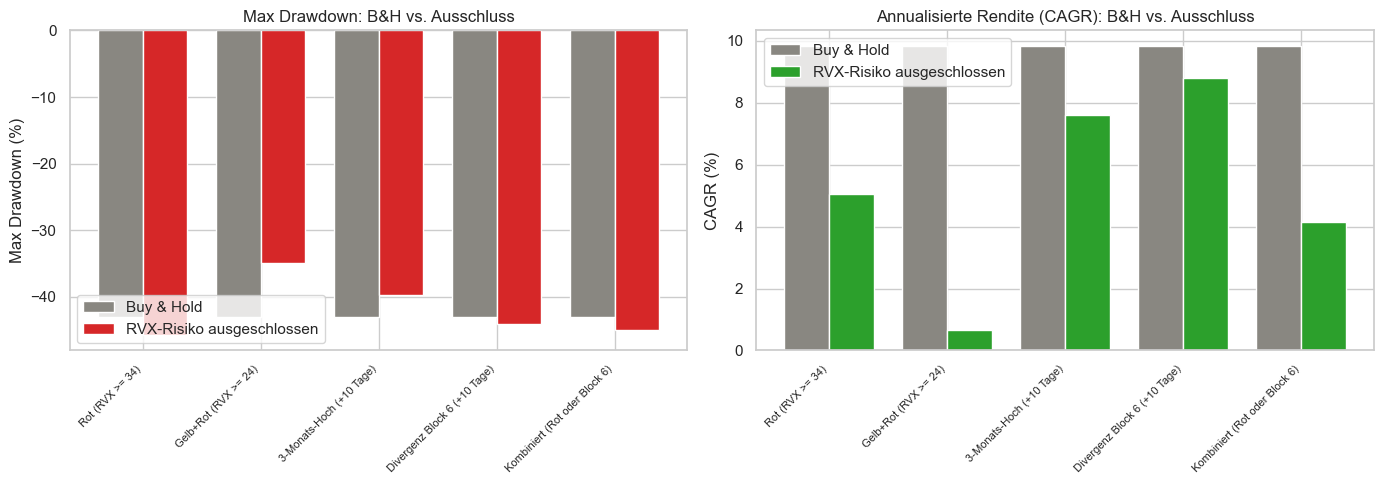

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(tabelle_www)); breite = 0.38
namen = tabelle_www["risikophase"]

ax1.bar(x - breite/2, tabelle_www["max_drawdown_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax1.bar(x + breite/2, tabelle_www["max_drawdown_strategie"]*100, breite, label="RVX-Risiko ausgeschlossen", color=COLOR_RED)
ax1.set_xticks(x); ax1.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Max Drawdown (%)"); ax1.set_title("Max Drawdown: B&H vs. Ausschluss"); ax1.legend()

ax2.bar(x - breite/2, tabelle_www["cagr_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax2.bar(x + breite/2, tabelle_www["cagr_strategie"]*100, breite, label="RVX-Risiko ausgeschlossen", color=COLOR_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("CAGR (%)"); ax2.set_title("Annualisierte Rendite (CAGR): B&H vs. Ausschluss"); ax2.legend()

plt.tight_layout(); plt.show()


**Ergebnis:** Buy & Hold erzielt über den Zeitraum 389 %
Gesamtrendite (CAGR 9,8 %) bei einem maximalen Drawdown von
−43,1 %. Über alle fünf Risikophasen hinweg **reduziert der
RVX-gestützte Ausschluss die Rendite** – wie beim VIX, anders als im
trendbasierten SMA-Notebook. Der Ausschluss der Rot-Tage (RVX ≥ 34,
9,1 % der Tage) drückt die CAGR auf 5,1 %, der Max
Drawdown verschärft sich leicht auf −45,8 %. Am aggressivsten wirkt Gelb+Rot
(RVX ≥ 24): Drawdown −34,9 %, CAGR aber nur noch 0,7 %.
Die ereignisbasierten Signale (3-Monats-Hoch, Block 6) bewegen die Gesamtbilanz
kaum.

**Ursache:** Hohe RVX-Werte fallen historisch mit Markttiefpunkten und den
anschließenden, besonders kräftigen Erholungstagen zusammen. Wer an
Hoch-RVX-Tagen in Cash geht, vermeidet Verlusttage, verpasst aber auch die
stärksten Rebounds – der RVX wirkt als Risikoreduzierer, nicht als
Renditebringer (im Einklang mit H2).

### 6.4 Vertiefte Einzelbetrachtung ausgewählter Risikophasen

Für drei repräsentative Fälle wird der zeitliche Verlauf dargestellt: oben der
Russell 2000-Kurs mit rot hinterlegter Ausschlussphase, darunter die Wertentwicklung
von Buy & Hold gegenüber der Ausschluss-Strategie (logarithmische Skala,
Startwert = 1).


In [34]:
def plotte_was_waere_wenn(label, titel=None):
    ergebnis = was_waere_wenn(risiko_definitionen[label], label)
    risiko = risiko_definitionen[label].reindex(df.index).fillna(False).shift(1, fill_value=False)
    titel = titel or label

    fig, (ax_kurs, ax_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax_kurs.fill_between(df.index, 0, 1, where=risiko.values, color=COLOR_RED, alpha=0.15,
                         transform=ax_kurs.get_xaxis_transform())
    ax_kurs.plot(df.index, df["russell2000_close"], color=COLOR_PRICE, linewidth=0.9)
    ax_kurs.set_ylabel("Russell 2000 (Punkte)")
    ax_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene RVX-Risikophase")

    ax_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    ax_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_GREEN, label="RVX-Risiko ausgeschlossen")
    ax_equity.set_yscale("log")
    ax_equity.set_ylabel("Wertentwicklung (Start = 1, log.)")
    ax_equity.legend()

    fig.tight_layout(); plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_risikotage']:.1%}")
    print(f"Gesamtrendite - B&H: {ergebnis['gesamtrendite_buy_hold']:.0%} | Strategie: {ergebnis['gesamtrendite_strategie']:.0%}")
    print(f"CAGR         - B&H: {ergebnis['cagr_buy_hold']:.1%} | Strategie: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown - B&H: {ergebnis['max_drawdown_buy_hold']:.1%} | Strategie: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### Rot (RVX ≥ 34) ausgeschlossen


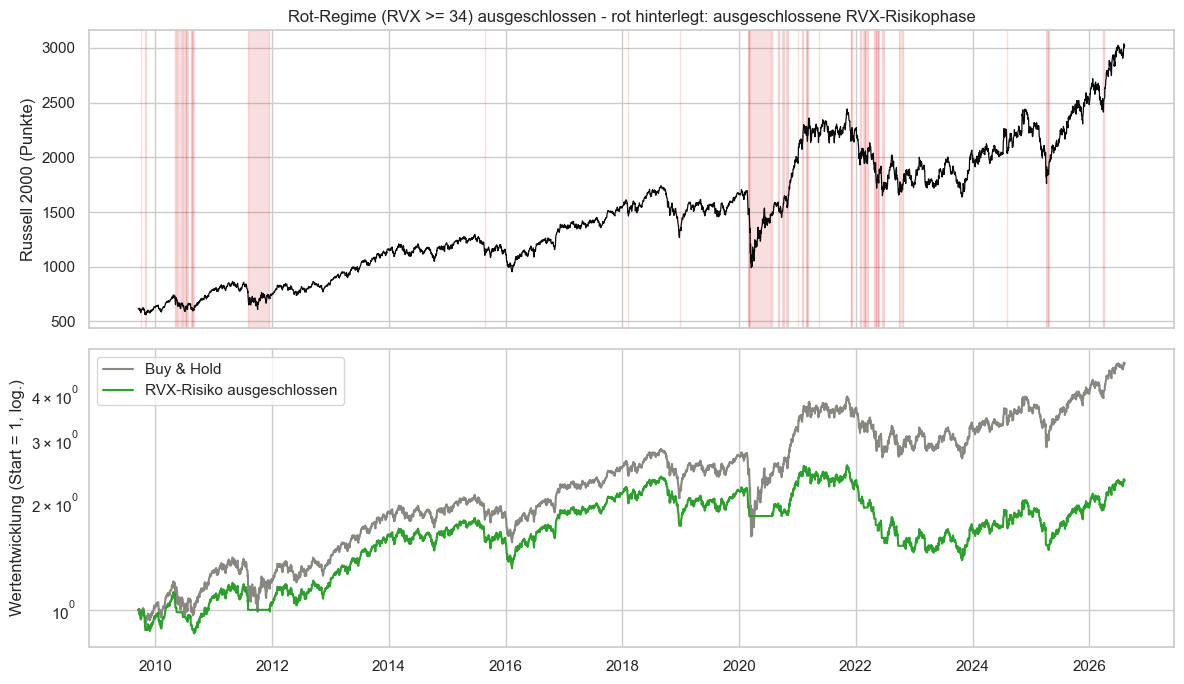

Anteil ausgeschlossener Handelstage: 9.1%
Gesamtrendite - B&H: 389% | Strategie: 130%
CAGR         - B&H: 9.8% | Strategie: 5.1%
Max Drawdown - B&H: -43.1% | Strategie: -45.8%


In [35]:
_ = plotte_was_waere_wenn("Rot (RVX >= 34)", "Rot-Regime (RVX >= 34) ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,1 % Rot-Tage verändert den
Max Drawdown von −43,1 % auf −45,8 % und drückt die CAGR von
9,8 % auf 5,1 % (Gesamtrendite 130 % statt
389 %). In den Crashphasen bleibt die Strategie flach, verpasst danach
aber die V-förmigen Erholungen und bleibt so unter Buy & Hold.

#### Gelb+Rot (RVX ≥ 24) ausgeschlossen


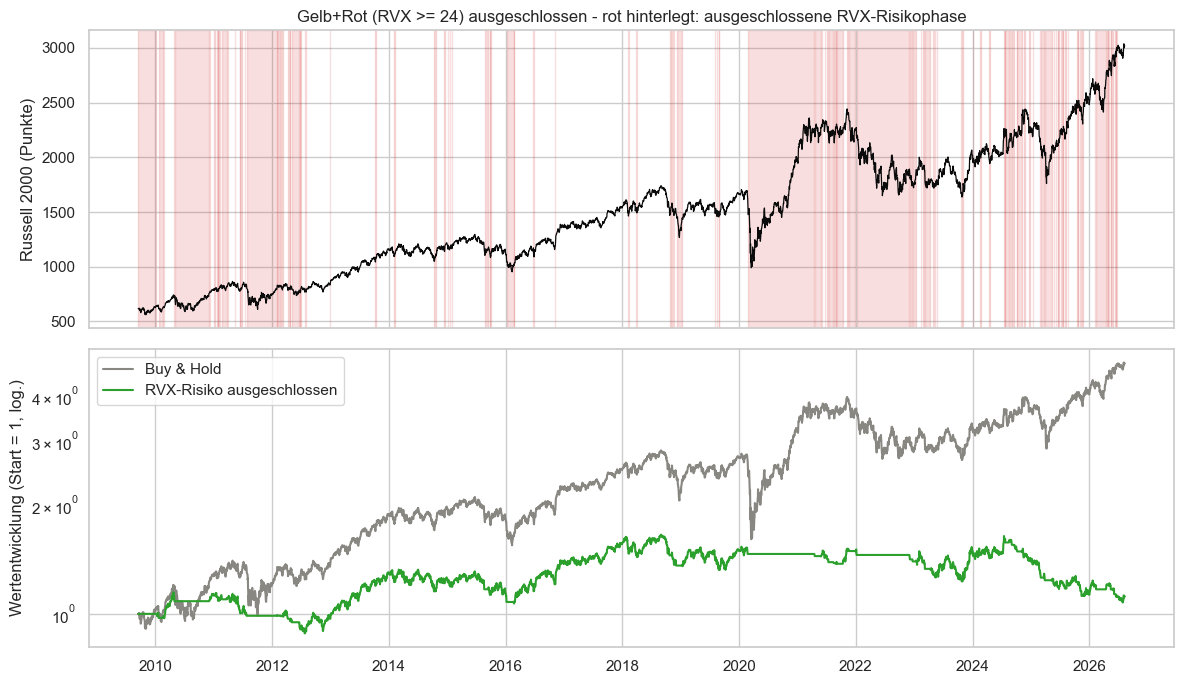

Anteil ausgeschlossener Handelstage: 37.5%
Gesamtrendite - B&H: 389% | Strategie: 12%
CAGR         - B&H: 9.8% | Strategie: 0.7%
Max Drawdown - B&H: -43.1% | Strategie: -34.9%


In [36]:
_ = plotte_was_waere_wenn("Gelb+Rot (RVX >= 24)", "Gelb+Rot (RVX >= 24) ausgeschlossen")


**Ergebnis:** Das aggressivste Filter (37,5 % der Tage in Cash)
senkt den Max Drawdown deutlich auf −34,9 %, kostet aber massiv Rendite:
Die CAGR sinkt auf 0,7 % (Gesamtrendite 12 % statt
389 %). Ein deutlich ruhigeres Depot – der Renditeverzicht ist jedoch
für die meisten Anlegerinnen zu hoch.

#### Kombinierte Regel (Rot oder Block 6) ausgeschlossen


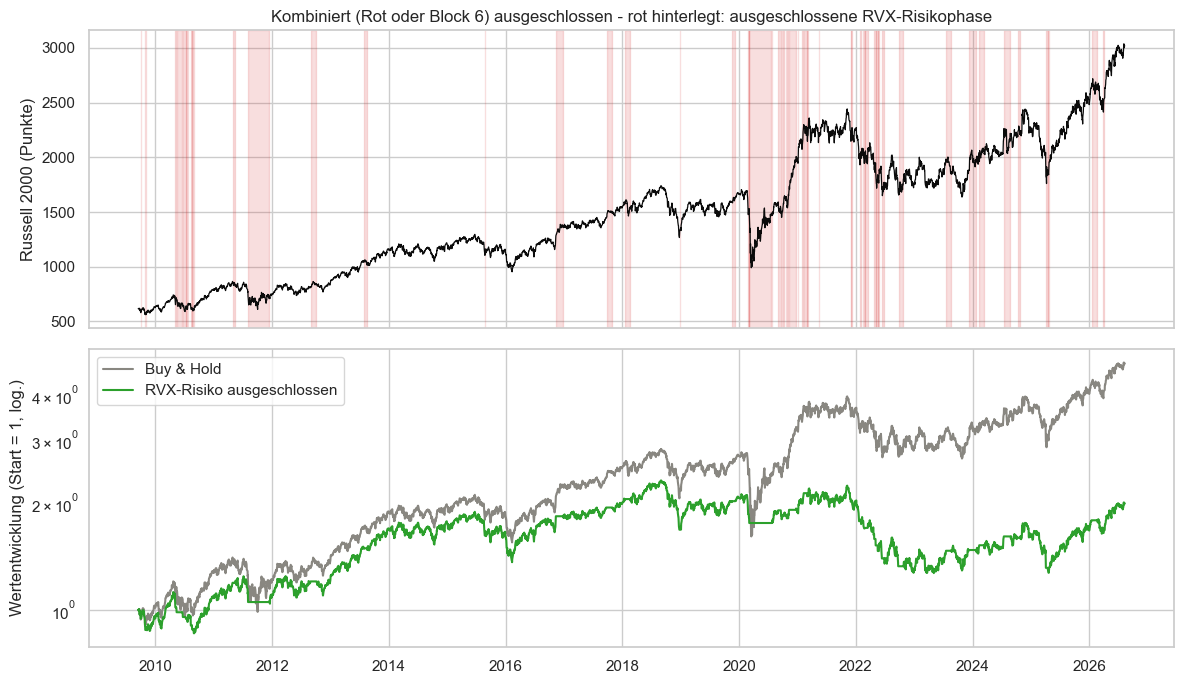

Anteil ausgeschlossener Handelstage: 16.6%
Gesamtrendite - B&H: 389% | Strategie: 98%
CAGR         - B&H: 9.8% | Strategie: 4.1%
Max Drawdown - B&H: -43.1% | Strategie: -45.0%


In [37]:
_ = plotte_was_waere_wenn("Kombiniert (Rot oder Block 6)", "Kombiniert (Rot oder Block 6) ausgeschlossen")


**Ergebnis:** Die Kombination (Rot oder Block 6, 16,6 % der Tage)
liegt nahe am reinen Rot-Ausschluss: Max Drawdown −45,0 %, CAGR
4,1 %. Der vorlaufende Block-6-Filter verbessert das aggregierte
Portfolio-Ergebnis also nicht spürbar – sein Wert liegt in der frühen
Einzelwarnung (Kapitel 5), nicht in der Portfolio-Steuerung.

**Zusammenfassende Einordnung:** Die Was-wäre-wenn-Analyse liefert den
zentralen, ehrlichen Befund: Ein RVX-gestützter Risikoausschluss **kostet
Rendite** (CAGR von 9,8 % auf 5,1 % bei Rot-Ausschluss);
die Drawdown-Wirkung reicht von gering (Rot) bis deutlich (Gelb+Rot:
−43,1 % → −34,9 %). Der Grund liegt in der Natur des RVX: Er
ist ein zeitgleicher Stressindikator, dessen Spitzen mit Tiefpunkten und den
darauffolgenden Erholungen zusammenfallen.

**Für das Ampelsystem** heißt das: Der Nutzen liegt in der Drawdown-Begrenzung
(sicherheitsorientierte Anlegerinnen), nicht in der Renditesteigerung. Die Ampel
sollte als **Risiko-, nicht als Renditesignal** kommuniziert werden. Alle Werte
beruhen auf einer vereinfachten Simulation ohne Transaktionskosten und
Cash-Verzinsung und markieren ein oberes Potenzial.

## 7. Fazit und Handlungsempfehlungen

Die explorative Analyse überträgt die VIX-Methodik auf den RVX und bestätigt,
dass auch für den Russell 2000 ein volatilitätsbasiertes Ampelsystem auf solider
empirischer Grundlage steht. Die Ampel-Schwellen wurden **datenbasiert** aus der
RVX-Verteilung abgeleitet – **Grün < 24, Gelb 24–34, Rot ≥ 34**
(Anteile 62,5 % / 28,4 % / 9,1 %, vergleichbar zum
VIX mit 64/27/9 %).

**Basis-Exploration (H1–H5):**

- **H1 (Stressphasen):** Bestätigt. Deutliche Ausschläge nur in realen Krisen;
  nach RVX > 34 folgt eine überdurchschnittliche
  Russell 2000-Rendite (+5,28 % über 30 T) bei tieferem Max Drawdown.
- **H2 (RVX vs. Russell 2000):** Bestätigt für die Tagesänderung (r = −0,756),
  nicht für das Niveau (r = −0,113) – Zustands-, kein Richtungsindikator.
- **H3 (Volatility Clustering):** Bestätigt. Autokorrelation 0,974 (Lag 1) /
  0,903 (Lag 5).
- **H4 (Verteilung & Schwellen):** Datenbasierte Schwellen 24/34 ergeben
  62,5 % / 28,4 % / 9,1 %.
- **H5 (Dauer der Ampelphasen):** Rot meist kurz (Median 3 Tage),
  in Krisen bis 96 Tage – Eskalationsregel bei mehrtägigem Rot sinnvoll.

**Vertiefende Hypothesen (H6–H9):**

- **H6 (Neues 3-Monats-Hoch):** Frühwarnsignal, Trefferquote (36,1 %
  in 10 T vs. Baseline 15,0 %). Forward-Rendite über Baseline bei
  tieferem Drawdown → markiert Risiko, nicht Richtung.
- **H7 (3-Punkte-Umkehr):** Beruhigungssignal (70,7 % mit
  fallendem RVX); als Russell 2000-Renditesignal leicht über
  der Baseline.
- **H8 (RVX-Schwellen):** Krisen-Median 32,9 stützt die
  Rot-Schwelle 34.
- **H9 (Divergenz):** In der Original-Definition nicht belastbar. Der 27er-Raster
  zeigt: die trennschärfsten Divergenz-Varianten sind die einzigen Signale mit
  *unter*durchschnittlicher Forward-Rendite (leicht bearish); Block 6 (20 T / 20 %)
  dient in Kapitel 5/6 als repräsentative Parametrisierung.

**Querschnittsbefund der Forward-Kennzahlen:** Erhöhte RVX-Stände sowie die
Signale 3-Monats-Hoch und 3-Punkte-Umkehr gehen mit über- oder mindestens
durchschnittlichen Folgerenditen bei *tieferen* Drawdowns einher – der RVX ist
ein Risiko-, kein Richtungsindikator. Die Divergenz ist die einzige Ausnahme mit
unterdurchschnittlicher Folgerendite.

Die **Was-wäre-wenn-Analyse** (Abschnitt 6) zeigt: Ein RVX-gestützter Ausschluss
von Risikophasen senkt zwar bei aggressiver Auslegung (Gelb+Rot) den Max Drawdown
deutlich (−43,1 % → −34,9 %), kostet aber Rendite (CAGR
9,8 % → 5,1 % bei Rot-Ausschluss) – der RVX wirkt als
Risiko-, nicht als Renditesignal.

**Abgeleitete Ampel-Logik (erster Entwurf):**

| Ampelfarbe | Basis-Kriterium | Optionaler Zusatzhinweis |
|---|---|---|
| Grün | RVX < 24 | „Vorsicht"-Flag bei aktivem 3-Monats-Hoch-Signal (H6) |
| Gelb | 24 ≤ RVX < 34 | – |
| Rot | RVX ≥ 34 | Hinweis „mögliche baldige Beruhigung" bei 3-Punkte-Umkehr (H7) |

**Nächste Schritte:** Ampel-Logik inkl. Zusatzsignale als wiederverwendbare
Funktion(en) in `src/` implementieren, einen historischen Backtest der
kombinierten Regel durchführen und die Ergebnisse der drei Volatilitätsindizes
(VIX, RVX und die übrigen) vergleichend gegenüberstellen.